## 1. Load ADB File

In [4]:
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the geojson file
filepath = 'you_adb_dataset_path.geojson'
gdf = gpd.read_file(filepath)

# Display the first few rows of the GeoDataFrame
gdf.head()

,OBJECTID,english_ro,OvertureID,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,SpeedLimit,RoadClass,...,InvPercentile,AnalysisStatus,RankedPercentile,StreetImageLink,LandUse,NO_OF_Result_Segments,PercentileBand,SampleSizeTotal,Shape_Length,geometry
0,1,Surin Ring Road,1,NaN,4.632086,NaN,NaN,NaN,NaN,primary,...,NaN,Not Included,NaN,"103.4699393,14.839138,103.43891053,14.86699584",None,NaN,None,NaN,4632.086492,"LINESTRING (103.46994 14.83914, 103.46967 14.8..."
1,2,Surin Ring Road,2,44479.6,2.300000,102303.08,0.000002,0.002591,66.0,primary,...,0.997409,Valid,26.253458,"103.43891053,14.86699584,103.48332214,14.94166589",RURAL,1.0,0-5%,222398.0,11672.918346,"LINESTRING (103.43891 14.867, 103.4383 14.8677..."
2,3,Surin Ring Road,3,NaN,0.122010,NaN,NaN,NaN,NaN,primary,...,NaN,Not Included,NaN,"103.48332214,14.94166589,103.48440114,14.94199564",None,NaN,None,NaN,122.010111,"LINESTRING (103.48332 14.94167, 103.48405 14.9..."
3,4,Surin Ring Road,4,NaN,2.045467,NaN,NaN,NaN,NaN,primary,...,NaN,Not Included,NaN,"103.48440114,14.94199564,103.50325276,14.94199566",None,NaN,None,NaN,2045.467119,"LINESTRING (103.4844 14.942, 103.4846 14.94205..."
4,5,Surin Ring Road,5,NaN,2.028143,NaN,NaN,NaN,NaN,primary,...,NaN,Not Included,NaN,"103.50325276,14.94199566,103.5216215,14.9380875",None,NaN,None,NaN,2028.142985,"LINESTRING (103.50325 14.942, 103.5072 14.9411..."


--- Sample Data with Percentage Difference ---
   SpeedLimit  F85thPercentileSpeed  Speed_Diff_Pct
0         NaN                   NaN             NaN
1        66.0                 115.2       74.545455
2         NaN                   NaN             NaN
3         NaN                   NaN             NaN
4         NaN                   NaN             NaN

--- Summary Statistics of Speed Difference (%) ---
count    11134.000000
mean        -1.000427
std         30.204082
min        -81.333333
25%        -17.053377
50%         -1.785131
75%         12.222222
max        400.000000
Name: Speed_Diff_Pct, dtype: float64

--- Average Speed Difference (%) by Speed Limit ---
 SpeedLimit  Speed_Diff_Pct
        0.0             NaN
       20.0      241.250000
       30.0      152.935768
       40.0       65.584524
       42.0      192.380952
       45.0        6.666667
       46.0       36.714976
       50.0       52.246507
       52.0       47.596154
       53.0       31.132075
       55.0    

/tmp/ipykernel_96/4281714307.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gdf, x='SpeedLimit', y='Speed_Diff_Pct', palette='coolwarm')


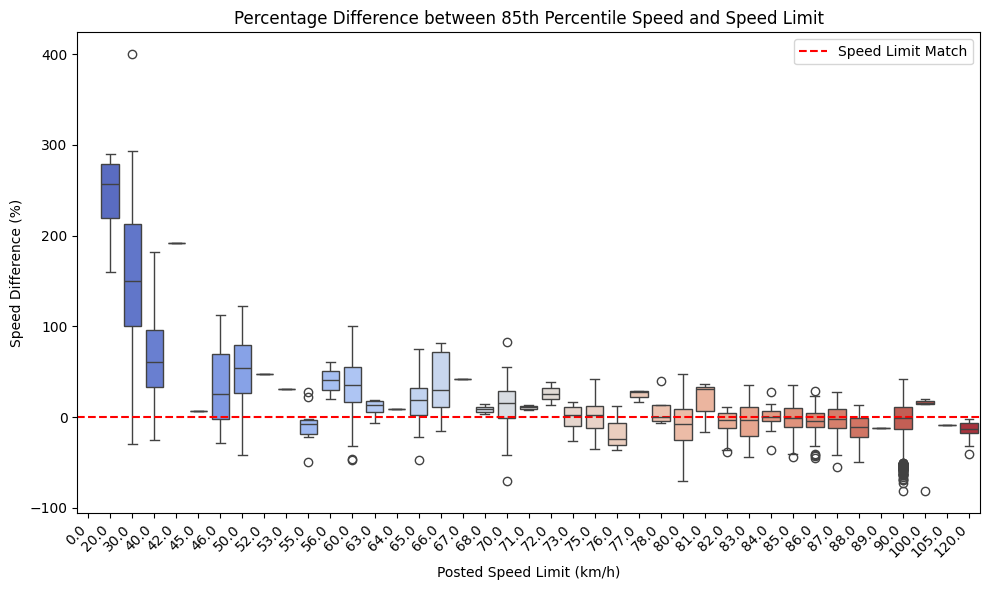

In [5]:
gdf['MedianSample'] = gdf['WeightedSample'] * 0.5
gdf['F85thSample'] = gdf['WeightedSample'] * 0.15

# 1. Calculate the percentage difference safely
# (Handles cases where SpeedLimit is 0, NaN, or infinite)
gdf['Speed_Diff_Pct'] = np.where(
    (gdf['SpeedLimit'] > 0) & gdf['SpeedLimit'].notna() & gdf['F85thPercentileSpeed'].notna(),
    ((gdf['F85thPercentileSpeed'] - gdf['SpeedLimit']) / gdf['SpeedLimit']) * 100,
    np.nan
)

# 2. View a few rows of the updated dataframe
print("--- Sample Data with Percentage Difference ---")
print(gdf[['SpeedLimit', 'F85thPercentileSpeed', 'Speed_Diff_Pct']].head())

# 3. Get descriptive statistics of the percentage difference
print("\n--- Summary Statistics of Speed Difference (%) ---")
print(gdf['Speed_Diff_Pct'].describe())

# 4. Find the average percentage difference grouped by speed limit
# (Helps you identify which speed limits have the worst speeding violations)
print("\n--- Average Speed Difference (%) by Speed Limit ---")
avg_diff_by_limit = gdf.groupby('SpeedLimit')['Speed_Diff_Pct'].mean().reset_index()
print(avg_diff_by_limit.to_string(index=False))

# 5. Visualize the percentage differences
plt.figure(figsize=(10, 6))
sns.boxplot(data=gdf, x='SpeedLimit', y='Speed_Diff_Pct', palette='coolwarm')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Speed Limit Match')
plt.title('Percentage Difference between 85th Percentile Speed and Speed Limit')
plt.xlabel('Posted Speed Limit (km/h)')
plt.ylabel('Speed Difference (%)')
plt.legend()
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 2. Pre-processing adb dataset to accident dataset

In [6]:
# Load thailand public accident dataset 2025 - closer to ADB dataset collection in 2025
public_thai_dataset = "./processed_thai_accident_2025_original.geojson"
df = gpd.read_file(public_thai_dataset)

# Selecting specifics columns
selected_speeding_cols = ['deaths','severe_injured','minorly_injured','total_injured','geometry']
df.columns = ['ProvinceID'] + selected_speeding_cols
df.head()

,ProvinceID,deaths,severe_injured,minorly_injured,total_injured,geometry
0,14,0,0,1,1,POINT (100.54889 14.46947)
1,20,0,0,0,0,POINT (101.28118 13.39719)
2,91,0,0,1,1,POINT (99.8467 6.98839)
3,11,0,0,1,1,POINT (100.53543 13.66435)
4,61,0,4,0,4,POINT (100.02193 15.45203)


In [8]:
import numpy as np

def skew_angle(geom):
    """
    Calculates the interior angle of a LineString.
    180° = perfectly straight road
    90°  = sharp curved road (perpendicular)
    <90° = extreme curve
    """
    coords = list(geom.coords)

    if len(coords) < 3:
        # Only 2 points — use start/mid/end fallback
        # Can't compute interior angle, assume straight
        return 180.0

    # Use start, middle, and end point to get the bend angle
    mid_idx = len(coords) // 2
    p1 = np.array(coords[0])
    p2 = np.array(coords[mid_idx])   # vertex / bend point
    p3 = np.array(coords[-1])

    # Vectors from midpoint outward
    v1 = p1 - p2
    v2 = p3 - p2

    # Cosine of angle between the two vectors
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)   # guard floating point

    angle = np.degrees(np.arccos(cos_angle))

    return round(angle, 2)

def classify_skew(angle):
    if angle >= 160:
        return 0          # ~180° flat straight
    elif angle >= 135:
        return 1     # ~150° slightly curved
    elif angle >= 110:
        return 2  # ~120° moderate curved
    elif angle >= 90:
        return 3          # ~90–110°  curved
    else:
        return 4        # <90° sharp turn

gdf['skew_angle'] = gdf.geometry.apply(skew_angle)
gdf['skew_class'] = gdf['skew_angle'].apply(classify_skew)

In [9]:
# Give 5 meters buffer to linestring
gdf_cop = gdf[gdf['AnalysisStatus'] == 'Valid'].copy()
gdf_cop['save_geometry_linestring'] = gdf_cop['geometry'].astype(str)
gdf_cop['geometry'] = gdf_cop['geometry'].to_crs('EPSG:3857').buffer(5).to_crs('EPSG:4326')

# We plan to remove all the bias of safe road
gdf_merged = gpd.sjoin(gdf_cop,df[selected_speeding_cols],predicate='intersects',how='left').dropna()
gdf_merged['total_accidents'] = 1
print("First merged shape",gdf_merged.shape)
# Aggregate the accident data into per road

grouped_gdf = gdf_merged.groupby('OBJECTID')[['deaths','severe_injured',
                                              'minorly_injured','total_injured','total_accidents']].sum().reset_index()

# Recombined to gdf merged
gdf_merged = pd.merge(gdf_cop,grouped_gdf,how='left',on='OBJECTID')
gdf_unmerged = gdf_merged[gdf_merged['deaths'].isnull()]
gdf_merged = gdf_merged.dropna()
print("Second merged shape",gdf_merged.shape)

del gdf_cop
gdf_merged.head()

First merged shape (9964, 39)
Second merged shape (2990, 38)


,OBJECTID,english_ro,OvertureID,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,SpeedLimit,RoadClass,...,F85thSample,Speed_Diff_Pct,skew_angle,skew_class,save_geometry_linestring,deaths,severe_injured,minorly_injured,total_injured,total_accidents
9,30,Kanchanaphisek Road,30,3225895.0,7.8,25161981.0,0.000480,0.265749,80.0,motorway,...,3.774297e+06,32.500000,166.54,0,"LINESTRING (100.517864 13.623928, 100.514639 1...",0.0,0.0,2.0,2.0,3.0
10,33,Kanchanaphisek Road,33,5754773.0,8.4,48340093.2,0.000923,0.351231,85.0,motorway,...,7.251014e+06,10.000000,168.27,0,"LINESTRING (100.412635 13.63907, 100.412914 13...",1.0,0.0,23.0,23.0,18.0
11,37,Kanchanaphisek Road,37,30302849.0,7.7,233331937.3,0.004454,0.560089,120.0,motorway,...,3.499979e+07,-10.000000,172.00,0,"LINESTRING (100.712815 13.970289, 100.712866 1...",0.0,4.0,38.0,42.0,58.0
12,38,Kanchanaphisek Road,38,10339718.0,3.1,32053125.8,0.000612,0.292054,120.0,motorway,...,4.807969e+06,-3.888889,165.66,0,"LINESTRING (100.695672 14.075329, 100.695361 1...",0.0,2.0,2.0,4.0,7.0
13,39,Kanchanaphisek Road,39,10344319.0,4.7,48618299.3,0.000928,0.352159,120.0,motorway,...,7.292745e+06,-7.222222,179.97,0,"LINESTRING (100.672656 14.125329, 100.671158 1...",0.0,1.0,10.0,11.0,22.0


## 3. Add cluster column as feature

In [12]:
"""
Road Safety DBSCAN Clustering
==============================
Goal      : Identify high-risk road segments using speed behaviour
            and road characteristics. 'death' is excluded (it's your Y variable).
Algorithm : DBSCAN (density-based, no k needed, handles noise/outliers well)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# ─────────────────────────────────────────────────────────────
# 1. LOAD YOUR DATA
# ─────────────────────────────────────────────────────────────
# Uses gdf_merged — assumed to already be in memory from your notebook.
# The geometry column is excluded from clustering automatically (see EXCLUDE list).

print(f"Dataset loaded: {gdf_merged.shape[0]:,} rows x {gdf_merged.shape[1]} columns\n")


# ─────────────────────────────────────────────────────────────
# 2. FEATURE SELECTION
# ─────────────────────────────────────────────────────────────
# Speed-related features
SPEED_FEATURES = [
    "SpeedLimit",
    "MedianSpeed",
    "F85thPercentileSpeed",
    "PercentOverLimit",
    "NumberOverLimit",
    "Speed_Diff_Pct",       # how much actual speed exceeds limit (%)
    "InvPercentile",        # inverted percentile (higher = worse)
    "RankedPercentile",
]

# Road characteristic features
ROAD_FEATURES = [
    "RoadLength",
    "Shape_Length",
    "NO_OF_Result_Segments",
    "SampleSize_avg",
    "SampleSizeTotal",
    "skew_angle",
]

# Categorical features to encode
CATEGORICAL_FEATURES = [
    "RoadClass",
    "LandUse",
    "skew_class",
]

# Explicitly EXCLUDED
EXCLUDE = [
    "deaths",           # Y variable
    "geometry",        # geometry column
    "OBJECTID", "english_ro", "OvertureID",   # IDs
    "StreetImageLink", "AnalysisStatus",       # non-analytical strings
    "ProvinceID",                              # could be included if needed
    "PercentileBand",                          # ordinal — use RankedPercentile instead
    "ForAnalysis",                             # flag, not a feature
]

ALL_FEATURES = SPEED_FEATURES + ROAD_FEATURES

print("=" * 55)
print("FEATURES USED FOR CLUSTERING")
print("=" * 55)
print(f"\n Speed features  ({len(SPEED_FEATURES)}): {SPEED_FEATURES}")
print(f"\n Road features   ({len(ROAD_FEATURES)}): {ROAD_FEATURES}")
print(f"\n Categorical     ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"\n Excluded        (not used in clustering): {EXCLUDE}")


# ─────────────────────────────────────────────────────────────
# 3. PREPROCESSING
# ─────────────────────────────────────────────────────────────
df_model = gdf_merged[ALL_FEATURES + CATEGORICAL_FEATURES].copy()

# 3a. Encode categoricals
le = LabelEncoder()
for col in CATEGORICAL_FEATURES:
    df_model[col + "_enc"] = le.fit_transform(df_model[col].astype(str))

ENCODED_CATS = [c + "_enc" for c in CATEGORICAL_FEATURES]
FINAL_FEATURES = ALL_FEATURES + ENCODED_CATS

# 3b. Keep numeric only
X = df_model[FINAL_FEATURES].copy()

# 3c. Handle missing values (median imputation)
missing_before = X.isnull().sum().sum()
X = X.fillna(X.median(numeric_only=True))
print(f"\n[Preprocessing] Missing values imputed: {missing_before}")

# 3d. Clip extreme outliers (IQR-based, 1.5×)
for col in X.columns:
    Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    IQR = Q3 - Q1
    X[col] = X[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# 3e. Standard scaling (DBSCAN is distance-based)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"[Preprocessing] Features scaled: {X_scaled.shape[1]} features, {X_scaled.shape[0]:,} rows")

# ─────────────────────────────────────────────────────────────
# 3f. PCA REDUCTION  ← KEY FIX for high-dimensional DBSCAN
# ─────────────────────────────────────────────────────────────
# With 17 features, distances inflate (curse of dimensionality) causing
# DBSCAN to see everything as equally close → 1 giant cluster.
# We reduce to the number of components that explain ≥85% variance.
pca_full = PCA(random_state=42).fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.searchsorted(cumvar, 0.85)) + 1
n_components = max(n_components, 3)   # at least 3 dims

pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"[PCA] Reduced {X_scaled.shape[1]} → {n_components} components "
      f"({cumvar[n_components-1]*100:.1f}% variance explained)")

# Plot explained variance
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(1, n_components + 1), pca.explained_variance_ratio_ * 100,
       color="#3B8BD4", alpha=0.8, label="Per component")
ax.plot(range(1, n_components + 1), cumvar[:n_components] * 100,
        color="#E8593C", marker="o", markersize=4, linewidth=1.5, label="Cumulative")
ax.axhline(85, color="#EF9F27", linestyle="--", linewidth=1, label="85% threshold")
ax.set_title("PCA Explained Variance (components used for DBSCAN)", fontsize=11)
ax.set_xlabel("Principal component")
ax.set_ylabel("Variance explained (%)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150, bbox_inches="tight")
plt.close()
print("[Output] Saved: pca_variance.png")


# ─────────────────────────────────────────────────────────────
# 4. TUNE DBSCAN: K-DISTANCE PLOT + EPS SWEEP
# ─────────────────────────────────────────────────────────────
MIN_SAMPLES = max(5, n_components * 2)   # rule of thumb: 2 × dims after PCA
print(f"\n[Tuning] min_samples set to {MIN_SAMPLES}  (2 × PCA dims)")

# 4a. K-distance plot on PCA-reduced data
print("[Tuning] Computing k-distance plot on PCA data ...")
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_dist = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

# Robust elbow: look in the bottom 80% of the curve (avoid the spike at the top)
search_region = k_dist[int(len(k_dist) * 0.05): int(len(k_dist) * 0.80)]
diffs2 = np.diff(np.diff(search_region))
elbow_local = np.argmax(np.abs(diffs2)) + 1
elbow_idx   = int(len(k_dist) * 0.05) + elbow_local
suggested_eps = round(float(k_dist[elbow_idx]), 3)
print(f"[Tuning] Suggested eps from k-distance elbow: {suggested_eps}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_dist, color="#3B8BD4", linewidth=1.5)
ax.axhline(suggested_eps, color="#E8593C", linestyle="--", linewidth=1.2,
           label=f"Suggested eps = {suggested_eps}")
ax.axvline(elbow_idx, color="#EF9F27", linestyle=":", linewidth=1.2,
           label=f"Elbow @ index {elbow_idx}")
ax.set_title(f"{MIN_SAMPLES}-Distance Plot on PCA data — pick the elbow for eps",
             fontsize=12, fontweight="500")
ax.set_xlabel("Points sorted by distance (descending)")
ax.set_ylabel(f"{MIN_SAMPLES}-NN distance")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("kdistance_plot.png", dpi=150, bbox_inches="tight")
plt.close()
print("[Output] Saved: kdistance_plot.png")

# 4b. Eps sweep — find the eps that gives the most meaningful cluster structure
print("\n[Tuning] Sweeping eps values to find best cluster structure ...")
eps_candidates = np.linspace(k_dist[int(len(k_dist)*0.30)],   # 30th percentile distance
                              k_dist[int(len(k_dist)*0.02)],   # 2nd percentile distance
                              20)

sweep_results = []
for eps_try in eps_candidates:
    lbl_try = DBSCAN(eps=eps_try, min_samples=MIN_SAMPLES, n_jobs=-1).fit_predict(X_pca)
    n_clust = len(set(lbl_try)) - (1 if -1 in lbl_try else 0)
    n_nois  = (lbl_try == -1).sum()
    noise_p = n_nois / len(lbl_try) * 100
    # Silhouette only meaningful with 2+ clusters and <95% noise
    sil = np.nan
    valid = lbl_try[lbl_try != -1]
    if n_clust >= 2 and len(valid) > 10:
        sil = silhouette_score(X_pca[lbl_try != -1], valid,
                               sample_size=min(3000, len(valid)))
    sweep_results.append({
        "eps": round(eps_try, 3),
        "n_clusters": n_clust,
        "noise_pct": round(noise_p, 1),
        "silhouette": round(sil, 4) if not np.isnan(sil) else np.nan,
    })
    print(f"  eps={eps_try:.3f}  clusters={n_clust:>3}  noise={noise_p:5.1f}%  "
          f"silhouette={sil:.4f}" if not np.isnan(sil) else
          f"  eps={eps_try:.3f}  clusters={n_clust:>3}  noise={noise_p:5.1f}%  silhouette=n/a")

sweep_df = pd.DataFrame(sweep_results)

# Best eps: 2–8 clusters, noise 5–40%, highest silhouette
good = sweep_df[
    (sweep_df["n_clusters"].between(2, 8)) &
    (sweep_df["noise_pct"].between(3, 45)) &
    (sweep_df["silhouette"].notna())
]
if len(good) > 0:
    best_row = good.loc[good["silhouette"].idxmax()]
    EPS = best_row["eps"]
    print(f"\n[Tuning] ✓ Best eps from sweep: {EPS}  "
          f"(clusters={int(best_row['n_clusters'])}, "
          f"noise={best_row['noise_pct']}%, "
          f"silhouette={best_row['silhouette']:.4f})")
else:
    # Fallback: pick eps giving the most clusters without >60% noise
    fallback = sweep_df[sweep_df["noise_pct"] < 60].copy()
    if len(fallback) > 0:
        best_row = fallback.loc[fallback["n_clusters"].idxmax()]
    else:
        best_row = sweep_df.iloc[len(sweep_df)//2]
    EPS = best_row["eps"]
    print(f"\n[Tuning] ⚠ No ideal eps found — using fallback eps={EPS} "
          f"(clusters={int(best_row['n_clusters'])}, noise={best_row['noise_pct']}%)")
    print("  → Consider reviewing kdistance_plot.png and setting EPS manually below.")

# Plot the sweep
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(sweep_df["eps"], sweep_df["n_clusters"], color="#3B8BD4", marker="o", ms=4)
axes[0].axvline(EPS, color="#E8593C", linestyle="--", linewidth=1.2)
axes[0].set_title("Clusters vs eps"); axes[0].set_xlabel("eps"); axes[0].set_ylabel("# clusters")
axes[0].grid(True, alpha=0.2)

axes[1].plot(sweep_df["eps"], sweep_df["noise_pct"], color="#EF9F27", marker="o", ms=4)
axes[1].axvline(EPS, color="#E8593C", linestyle="--", linewidth=1.2)
axes[1].axhspan(3, 45, alpha=0.08, color="green", label="Target range 3–45%")
axes[1].set_title("Noise % vs eps"); axes[1].set_xlabel("eps"); axes[1].set_ylabel("Noise %")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.2)

sil_valid = sweep_df.dropna(subset=["silhouette"])
if len(sil_valid) > 0:
    axes[2].plot(sil_valid["eps"], sil_valid["silhouette"], color="#1D9E75", marker="o", ms=4)
    axes[2].axvline(EPS, color="#E8593C", linestyle="--", linewidth=1.2)
axes[2].set_title("Silhouette vs eps"); axes[2].set_xlabel("eps"); axes[2].set_ylabel("Silhouette score")
axes[2].grid(True, alpha=0.2)

plt.suptitle(f"DBSCAN eps sweep  |  Selected eps = {EPS}  |  min_samples = {MIN_SAMPLES}",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("eps_sweep.png", dpi=150, bbox_inches="tight")
plt.close()
print("[Output] Saved: eps_sweep.png")

# ── MANUAL OVERRIDE ──────────────────────────────────────────
# If the auto-selected EPS still gives 1 cluster, uncomment and
# set a value from the eps_sweep.png "Clusters vs eps" chart:
# EPS = 0.8
# ─────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────
# 5. RUN DBSCAN  (on PCA-reduced data)
# ─────────────────────────────────────────────────────────────
print(f"\n[DBSCAN] Running with eps={EPS}, min_samples={MIN_SAMPLES} on {n_components}-component PCA data ...")
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric="euclidean", n_jobs=-1)
labels = dbscan.fit_predict(X_pca)   # ← PCA-reduced data

gdf_merged["cluster"] = labels

n_clusters  = len(set(labels)) - (1 if -1 in labels else 0)
n_noise     = (labels == -1).sum()
noise_pct   = n_noise / len(labels) * 100

print(f"\n[DBSCAN Results]")
print(f"  Clusters found : {n_clusters}")
print(f"  Noise points   : {n_noise:,} ({noise_pct:.1f}%)")
print(f"\n  Cluster sizes:")
for lbl, cnt in sorted(pd.Series(labels).value_counts().items()):
    tag = "(noise)" if lbl == -1 else ""
    print(f"    Cluster {lbl:>3}: {cnt:>6,} rows  {tag}")

# Silhouette score (exclude noise)
mask = labels != -1
if mask.sum() > 1 and n_clusters > 1:
    sil = silhouette_score(X_pca[mask], labels[mask], sample_size=min(5000, mask.sum()))
    print(f"\n  Silhouette score (excl. noise): {sil:.4f}  (higher is better, range -1 to 1)")


# ─────────────────────────────────────────────────────────────
# 6. CLUSTER PROFILING — RISK CHARACTERISATION
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("CLUSTER PROFILES (mean values per cluster)")
print("=" * 55)

PROFILE_COLS = [
    "SpeedLimit", "MedianSpeed", "F85thPercentileSpeed",
    "PercentOverLimit", "Speed_Diff_Pct",
    "RoadLength", "NO_OF_Result_Segments",
    "skew_angle",
]

profile = gdf_merged.groupby("cluster")[PROFILE_COLS].mean().round(2)
profile["count"] = gdf_merged.groupby("cluster").size()

# Risk score: weighted sum of speed-over-limit indicators
profile["risk_score"] = (
    0.35 * profile["PercentOverLimit"] / 100 +
    0.30 * (profile["Speed_Diff_Pct"].clip(lower=0) / 60) +
    0.20 * (profile["F85thPercentileSpeed"] - profile["SpeedLimit"]).clip(lower=0) / 50 +
    0.15 * profile["skew_angle"].abs() / 45
)

# Rank clusters by risk (noise cluster last)
noise_row = profile.loc[-1].copy() if -1 in profile.index else None
profile_no_noise = profile.drop(index=-1, errors="ignore")
profile_sorted = profile_no_noise.sort_values("risk_score", ascending=False)
profile_sorted["risk_rank"] = range(1, len(profile_sorted) + 1)
if noise_row is not None:
    profile_sorted.loc[-1] = noise_row
    profile_sorted.loc[-1, "risk_rank"] = 999

print(profile_sorted[["count", "SpeedLimit", "MedianSpeed", "F85thPercentileSpeed",
                        "PercentOverLimit", "Speed_Diff_Pct", "risk_score", "risk_rank"]].to_string())

# Tag the highest-risk cluster
if len(profile_sorted) > 0:
    top_risk_cluster = profile_sorted[profile_sorted["risk_rank"] == 1].index[0]
    print(f"\n  ⚠  Highest-risk cluster: Cluster {top_risk_cluster}")


# ─────────────────────────────────────────────────────────────
# 7. VISUALISATIONS
# ─────────────────────────────────────────────────────────────
PALETTE = {
    -1: "#B4B2A9",   # noise = gray
    0:  "#3B8BD4",
    1:  "#E8593C",
    2:  "#1D9E75",
    3:  "#BA7517",
    4:  "#7F77DD",
    5:  "#D4537E",
    6:  "#639922",
    7:  "#888780",
}
def get_color(lbl):
    return PALETTE.get(lbl, "#888780")

unique_labels = sorted(gdf_merged["cluster"].unique())
colors = [get_color(l) for l in unique_labels]

# 7a. PCA 2D scatter (use first 2 components of the already-fitted PCA)
gdf_merged["pca1"] = X_pca[:, 0]
gdf_merged["pca2"] = X_pca[:, 1]
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

fig, ax = plt.subplots(figsize=(10, 7))
for lbl, col in zip(unique_labels, colors):
    mask = gdf_merged["cluster"] == lbl
    label_str = f"Noise ({mask.sum()})" if lbl == -1 else f"Cluster {lbl} (n={mask.sum():,})"
    alpha = 0.25 if lbl == -1 else 0.65
    size  = 8    if lbl == -1 else 20
    ax.scatter(gdf_merged.loc[mask, "pca1"], gdf_merged.loc[mask, "pca2"],
               c=col, label=label_str, alpha=alpha, s=size, linewidths=0)

ax.set_title("DBSCAN Clusters — PCA 2D Projection\n(Road safety segments)", fontsize=13)
ax.set_xlabel(f"PC1 ({pc1_var:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pc2_var:.1f}% variance)")
ax.legend(loc="best", fontsize=9, markerscale=2)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("dbscan_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.close()
print("[Output] Saved: dbscan_pca_scatter.png")

# 7b. Risk profile heatmap
fig, ax = plt.subplots(figsize=(10, max(4, len(profile_sorted) * 0.7 + 1)))
heat_cols = ["SpeedLimit", "MedianSpeed", "F85thPercentileSpeed",
             "PercentOverLimit", "Speed_Diff_Pct", "skew_angle", "risk_score"]
heat_data = profile_sorted[heat_cols].drop(index=-1, errors="ignore")
# Normalise each column 0-1 for colour comparability
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-9)
sns.heatmap(heat_norm, annot=heat_data.round(1), fmt="g",
            cmap="RdYlGn_r", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Normalised value (0=low, 1=high)"})
ax.set_title("Cluster Risk Profile Heatmap\n(red = higher risk indicator)", fontsize=12)
ax.set_ylabel("Cluster (sorted by risk)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("dbscan_risk_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
print("[Output] Saved: dbscan_risk_heatmap.png")

# 7c. Cluster size bar chart
fig, ax = plt.subplots(figsize=(8, 4))
cluster_counts = gdf_merged["cluster"].value_counts().sort_index()
bar_colors = [get_color(l) for l in cluster_counts.index]
bars = ax.bar(cluster_counts.index.astype(str), cluster_counts.values,
              color=bar_colors, edgecolor="white", linewidth=0.5)
ax.bar_label(bars, fmt="%d", fontsize=9, padding=3)
ax.set_title("Segment Count per Cluster  (-1 = noise)", fontsize=12)
ax.set_xlabel("Cluster label")
ax.set_ylabel("Number of road segments")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("dbscan_cluster_sizes.png", dpi=150, bbox_inches="tight")
plt.close()
print("[Output] Saved: dbscan_cluster_sizes.png")

# 7d. Speed violation distribution per cluster (box plot)
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = gdf_merged[gdf_merged["cluster"] != -1].copy()
# Newer seaborn (≥0.13) coerces x-axis values to str, so palette keys must match
plot_df["cluster_str"] = plot_df["cluster"].astype(str)
order = [str(l) for l in profile_sorted.index if l != -1]
palette_dict = {str(l): get_color(l) for l in profile_sorted.index if l != -1}
sns.boxplot(data=plot_df, x="cluster_str", y="PercentOverLimit",
            order=order, palette=palette_dict, linewidth=0.8, ax=ax)
ax.set_title("% Vehicles Over Speed Limit by Cluster", fontsize=12)
ax.set_xlabel("Cluster")
ax.set_ylabel("Percent over speed limit")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("dbscan_speed_violation_boxplot.png", dpi=150, bbox_inches="tight")
plt.close()
print("[Output] Saved: dbscan_speed_violation_boxplot.png")


# ─────────────────────────────────────────────────────────────
# 8. EXPORT RESULTS
# ─────────────────────────────────────────────────────────────
df_out = gdf_merged.copy()
df_out["risk_rank"] = df_out["cluster"].map(
    lambda c: profile_sorted.loc[c, "risk_rank"] if c in profile_sorted.index else 999
)
df_out["is_high_risk"] = (df_out["risk_rank"] == 1).astype(int)

output_cols = (
    ["OBJECTID", "english_ro", "cluster", "risk_rank", "is_high_risk"]
    + PROFILE_COLS
    + ["deaths"]          # keep death in export for downstream modelling
)
df_out[output_cols].to_csv("road_segments_clustered.csv", index=False)
print("\n[Output] Saved: road_segments_clustered.csv")
print(f"         High-risk segments (cluster {top_risk_cluster}): "
      f"{df_out['is_high_risk'].sum():,} rows")


# ─────────────────────────────────────────────────────────────
# 9. TIPS FOR TUNING DBSCAN
# ─────────────────────────────────────────────────────────────
print("""
════════════════════════════════════════════════════════
TUNING GUIDE
════════════════════════════════════════════════════════

eps (neighbourhood radius):
  • Look at kdistance_plot.png — choose the eps value
    at the "elbow" (where the curve bends sharply).
  • Too small → many noise points, tiny fragmented clusters.
  • Too large → everything merges into 1 cluster.

min_samples:
  • Rule of thumb: 2 × number_of_features (here ~28).
  • Increase if you want denser, more confident clusters.
  • Decrease if your data is sparse.

High noise % (>30%):
  • Increase eps slightly, or reduce min_samples.
  • Or pre-filter to ForAnalysis == 1 rows only.

Too few clusters (1-2 only):
  • Reduce eps.

Too many clusters (>10):
  • Increase eps.

For geospatial DBSCAN (using coordinates):
  • Use metric='haversine' and convert eps to radians:
    eps_rad = 0.5 / 6371   # 0.5 km in radians
════════════════════════════════════════════════════════
""")

Dataset loaded: 2,990 rows x 41 columns

FEATURES USED FOR CLUSTERING

 Speed features  (8): ['SpeedLimit', 'MedianSpeed', 'F85thPercentileSpeed', 'PercentOverLimit', 'NumberOverLimit', 'Speed_Diff_Pct', 'InvPercentile', 'RankedPercentile']

 Road features   (6): ['RoadLength', 'Shape_Length', 'NO_OF_Result_Segments', 'SampleSize_avg', 'SampleSizeTotal', 'skew_angle']

 Categorical     (3): ['RoadClass', 'LandUse', 'skew_class']

 Excluded        (not used in clustering): ['deaths', 'geometry', 'OBJECTID', 'english_ro', 'OvertureID', 'StreetImageLink', 'AnalysisStatus', 'ProvinceID', 'PercentileBand', 'ForAnalysis']

[Preprocessing] Missing values imputed: 0
[Preprocessing] Features scaled: 17 features, 2,990 rows
[PCA] Reduced 17 → 6 components (90.8% variance explained)
[Output] Saved: pca_variance.png

[Tuning] min_samples set to 12  (2 × PCA dims)
[Tuning] Computing k-distance plot on PCA data ...
[Tuning] Suggested eps from k-distance elbow: 2.28
[Output] Saved: kdistance_plot.png

## 3b. See linear-correlation with each variables

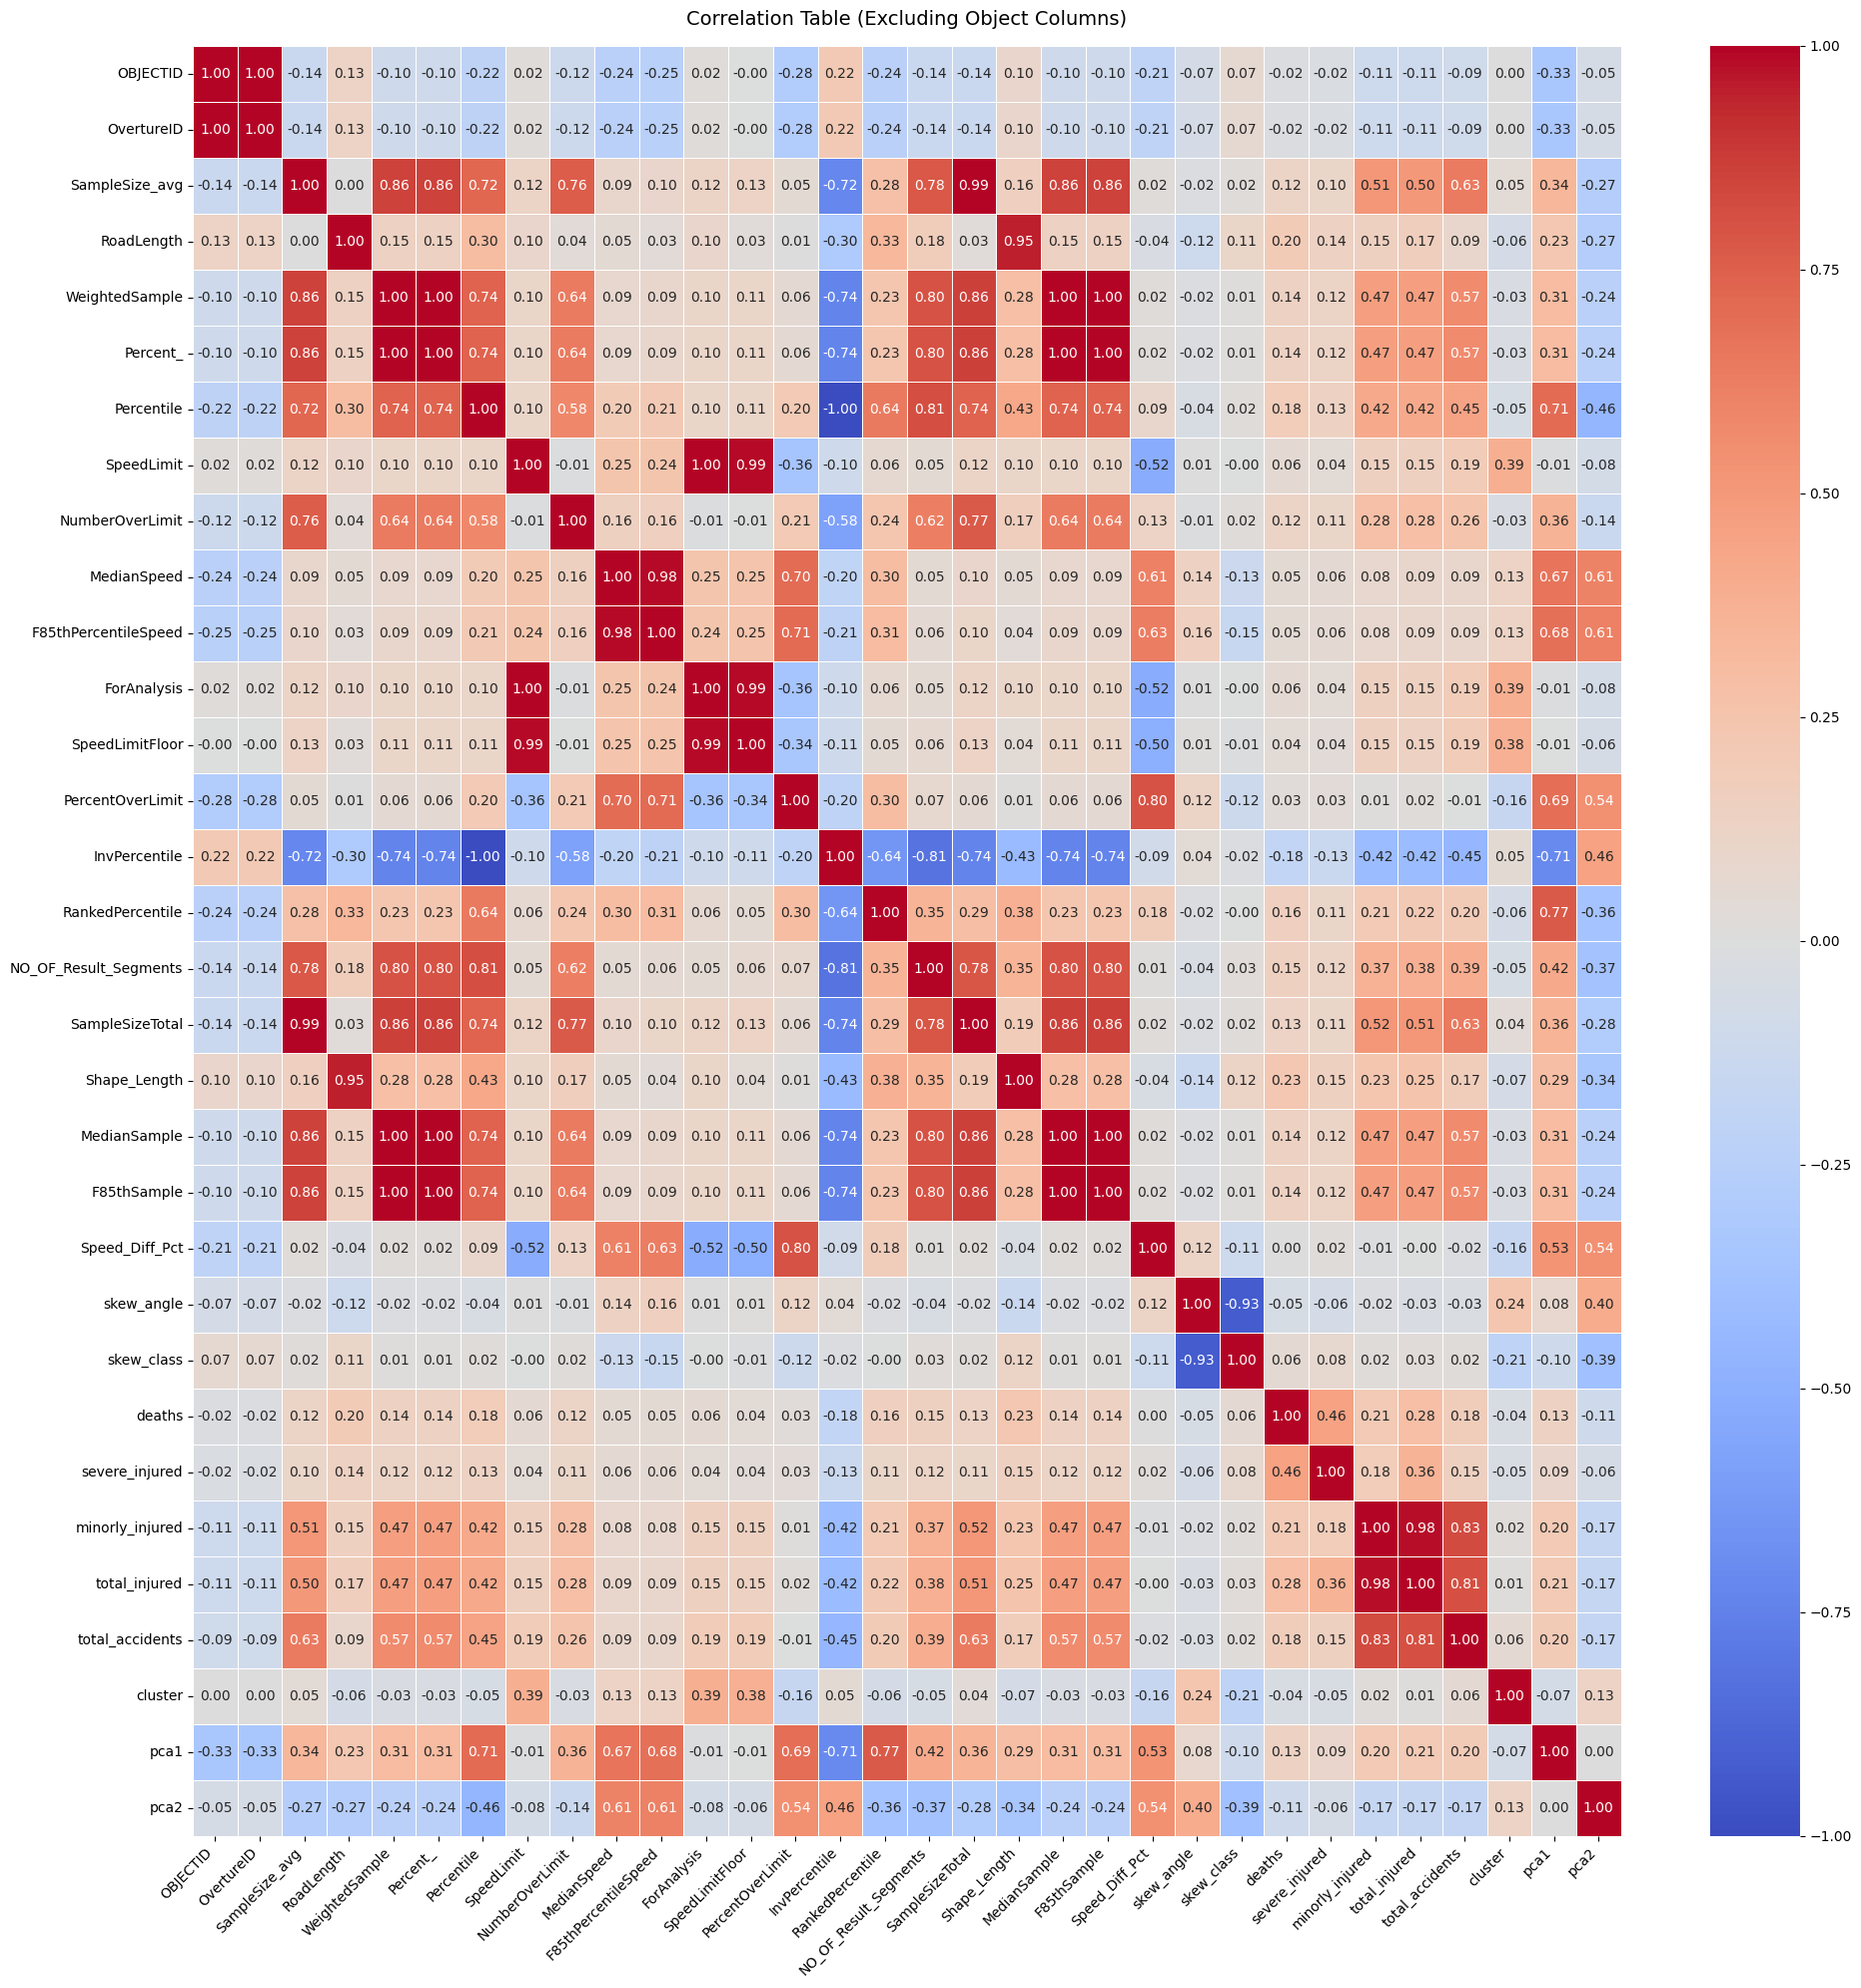

In [13]:
# Cleaning unimportant cols
# gdf_merged = gdf_merged.drop(['index_right','ProvinceID_right'],axis=1)
province_df = gdf_merged[gdf_merged['AnalysisStatus'] == 'Valid'].drop(["geometry",'save_geometry_linestring'],axis=1)
# province_df = province_df[province_df['presumed_cause'] == 'speeding']
# 1. Drop all columns with 'object' or 'category' data types
numeric_province_df = province_df.select_dtypes(exclude=["object", "category"])

# 2. Calculate the correlation matrix
corr_matrix = numeric_province_df.corr()

# 3. Create the heatmap visualization table
fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(
    corr_matrix,
    annot=True,  # Displays the correlation numbers
    cmap="coolwarm",  # Red = positive, Blue = negative correlation
    fmt=".2f",  # Limits decimals to 2 places
    linewidths=0.5,  # Adds clean separation gridlines
    ax=ax,
    vmin=-1,
    vmax=1,  # Standardizes the color scale
)

# 4. Format and clean up the labels
plt.title("Correlation Table (Excluding Object Columns)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# 5. Display the plot
plt.show()

## 4. Prepare training - testing dataset

In [16]:
# For training
df_clean = gdf_merged.copy()
df_clean = df_clean.rename(columns = {"deaths":"death"})
# For testing
df_clean_unmerged = gdf_unmerged.copy()
df_clean.head()

,OBJECTID,english_ro,OvertureID,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,SpeedLimit,RoadClass,...,skew_class,save_geometry_linestring,death,severe_injured,minorly_injured,total_injured,total_accidents,cluster,pca1,pca2
9,30,Kanchanaphisek Road,30,3225895.0,7.8,25161981.0,0.000480,0.265749,80.0,motorway,...,0,"LINESTRING (100.517864 13.623928, 100.514639 1...",0.0,0.0,2.0,2.0,3.0,0,4.722544,-0.310571
10,33,Kanchanaphisek Road,33,5754773.0,8.4,48340093.2,0.000923,0.351231,85.0,motorway,...,0,"LINESTRING (100.412635 13.63907, 100.412914 13...",1.0,0.0,23.0,23.0,18.0,0,3.704008,-1.533294
11,37,Kanchanaphisek Road,37,30302849.0,7.7,233331937.3,0.004454,0.560089,120.0,motorway,...,0,"LINESTRING (100.712815 13.970289, 100.712866 1...",0.0,4.0,38.0,42.0,58.0,1,3.456313,-1.728749
12,38,Kanchanaphisek Road,38,10339718.0,3.1,32053125.8,0.000612,0.292054,120.0,motorway,...,0,"LINESTRING (100.695672 14.075329, 100.695361 1...",0.0,2.0,2.0,4.0,7.0,1,3.754243,-0.687758
13,39,Kanchanaphisek Road,39,10344319.0,4.7,48618299.3,0.000928,0.352159,120.0,motorway,...,0,"LINESTRING (100.672656 14.125329, 100.671158 1...",0.0,1.0,10.0,11.0,22.0,1,3.275418,-1.155748


In [ ]:
chosen_Y = 'total_accidents'
exclude_rest = ['severe_injured','minorly_injured','total_injured',
                'secondary_location','death']
final_exclude = [x for x in exclude_rest if x != chosen_Y]
final_exclude

## 5. Running non-linear model with Poisson/Negative Binomial

In [17]:
!pip install doubleml econml libpysal esda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.7/607.7 kB 3.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 31.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 49.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 518.4/518.4 kB 24.8 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


## 5a. Predicting total accidents (first Y variable)

In [20]:
"""
fatality_count_model_v2_combined.py
====================================
Combined version of fatality_count_model_v2.py that runs the FULL modelling
pipeline (diagnostics, feature engineering, Models A/B/B_INT/within-stratum/
D/D+W, spatial autocorrelation, summary, calibration plot, and the road
safety score export) for BOTH target variables in a single script:

    1. TARGET = "total_accidents"  ->  road_safety_scores_accident.csv
    2. TARGET = "death"            ->  road_safety_scores_death.csv

Nothing else about the modelling logic has changed from fatality_count_model_v2.py.
The only two things that differ between the two runs are:
    - the target variable column used as y (TARGET)
    - the output CSV filename

Because the target column itself must not leak into the feature set, each
run also drops the *other* count column before feature engineering:
    - accident run  drops "death"            (as in the original script)
    - death run     drops "total_accidents"  (symmetric leakage guard)

Usage (notebook)
----------------
    # make sure df_clean (and optionally gdf_merged) are already in scope, then:
    %run fatality_count_model_v2_combined.py

Usage (standalone)
-------------------
    python fatality_count_model_v2_combined.py [path/to/csv] [path/to/geojson]
"""


def run_pipeline(TARGET, DROP_TARGET_COL, csv_filename):
    """
    fatality_count_model_v2.py
    ===========================
    Road-segment fatality count model with spatial autocorrelation.

    Improvements over v1
    ---------------------
    1.  Data loading fixed: df = df_clean.copy() or loaded from CSV.
    2.  Model A: exposure scaled to median so log(exposure) is well-conditioned.
    3.  New features: RoadClass dummies + PercentOverLimit (non-collinear with
        speed features already present).
    4.  Speed_Diff_Pct winsorised at 1st/99th pct to suppress extreme outliers.
    5.  [NEW] Spatial Autocorrelation section:
          a. Build a topological adjacency weight matrix W from LineString
             endpoints in the GeoJSON (roads that share an endpoint are
             neighbours — this captures the actual network structure).
          b. Moran's I test on NB (Model B) residuals and GBT (Model D) residuals.
          c. Spatial-Error NB model (Kelejian-Prucha-style) via libpysal/spreg
             if available; otherwise fall back to NB with clustered SEs by
             road corridor (OBJECTID cluster) which is the minimum-viable
             correction for network dependence when the spatial package is not
             installed.
          d. Interpretation guide printed for every spatial result.

    Usage (notebook)
    ----------------
        # make sure df_clean is already in scope, then:
        %run fatality_count_model_v2.py

    Usage (standalone)
    ------------------
        python fatality_count_model_v2.py [path/to/csv] [path/to/geojson]
        # defaults: sample_data.csv  +  matched_segments_gt70.geojson

    Requirements
    ------------
    Core (already in requirements.txt):
        pip install pandas numpy scipy scikit-learn statsmodels matplotlib seaborn

    Spatial (optional but highly recommended):
        pip install libpysal geopandas splot
    """

    import sys
    import warnings
    import json
    import numpy as np
    import pandas as pd
    from scipy.stats import spearmanr
    from sklearn.model_selection import LeaveOneOut, KFold, StratifiedKFold
    from sklearn.ensemble import HistGradientBoostingRegressor
    from sklearn.inspection import permutation_importance

    warnings.filterwarnings("ignore")

    # ── optional spatial stack ────────────────────────────────────────────────────
    try:
        import libpysal
        from libpysal.weights import W as PysalW
        from esda.moran import Moran
        HAS_PYSAL = True
    except ImportError:
        HAS_PYSAL = False

    try:
        import spreg
        HAS_SPREG = True
    except ImportError:
        HAS_SPREG = False

    # ── optional GLM stack ────────────────────────────────────────────────────────
    try:
        import statsmodels.api as sm
        from statsmodels.discrete.discrete_model import NegativeBinomial
        from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
        HAS_STATSMODELS = True
    except ImportError:
        HAS_STATSMODELS = False
        print("!! statsmodels not found — pip install statsmodels")

    import matplotlib
    matplotlib.use("Agg")          # headless; remove if you want interactive plots
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_theme(style="whitegrid", palette="muted")


    # ═══════════════════════════════════════════════════════════════════════════════
    # 0. LOAD DATA
    # ═══════════════════════════════════════════════════════════════════════════════
    # ── Path resolution — safe in both notebook and CLI contexts ─────────────────
    # In Jupyter/IPython, sys.argv[0] is the kernel connection file like:
    #   /root/.local/share/jupyter/runtime/kernel-xxxx.json
    # so sys.argv[1..] are NOT user-supplied paths. We detect this and fall back
    # to sensible defaults.

    def _is_kernel_argv(argv):
        """Return True if sys.argv looks like a Jupyter kernel invocation."""
        return (
            len(argv) < 2
            or "ipykernel" in argv[0]
            or "kernel" in argv[0]
            or argv[0].endswith(".json")
        )

    _notebook_mode = _is_kernel_argv(sys.argv)

    # ── Absolute defaults — edit these two lines to match your layout ─────────────
    _default_csv     = "/home/shemlim123/NKNHT_dev/nk_city_data/city_data_sample_and_code/sample_data.csv"
    _default_geojson = "/home/shemlim123/NKNHT_dev/nk_city_data/city_data_sample_and_code/matched_segments_gt70.geojson"
    # ─────────────────────────────────────────────────────────────────────────────
    # You can also override by setting these variables BEFORE calling %run:
    #   CSV_PATH     = "/path/to/your_full_data.csv"
    #   GEOJSON_PATH = "/path/to/your_network.geojson"

    if _notebook_mode:
        csv_path     = globals().get("CSV_PATH",     _default_csv)
        geojson_path = globals().get("GEOJSON_PATH", _default_geojson)
    else:
        csv_path     = sys.argv[1] if len(sys.argv) > 1 else _default_csv
        geojson_path = sys.argv[2] if len(sys.argv) > 2 else _default_geojson

    print(f"[config] CSV path     : {csv_path}")
    print(f"[config] GeoJSON path : {geojson_path}")

    # When called from the notebook, df_clean should already be in scope.
    # We try that first and fall back to reading the CSV.
    try:
        df = df_clean.copy()          # notebook context
        print(f"[load] Using df_clean from notebook scope  (n={len(df)})")
    except NameError:
        df = pd.read_csv(csv_path)
        print(f"[load] Read {csv_path}  (n={len(df)})")

    # ── Attach road geometry from gdf_merged (same index as df_clean) ─────────────
    # gdf_merged['save_geometry_linestring'] contains Shapely LineString objects
    # for each road segment. Index alignment is guaranteed because gdf_merged and
    # df_clean share the same integer index.
    try:
        df["geometry"] = gdf_merged["save_geometry_linestring"]
        _geom_count = df["geometry"].notna().sum()
        print(f"[load] Geometry attached from gdf_merged  ({_geom_count}/{len(df)} non-null)")
    except NameError:
        print("[load] gdf_merged not in scope — geometry column will be absent. "
              "Spatial adjacency will fall back to GeoJSON file.")

    # Drop the 'death' column — not the target any more; removing it prevents
    # accidental leakage into features and keeps the df focused on accident counts.
    df = df.drop(columns=[DROP_TARGET_COL], errors="ignore")
    df = df.reset_index(drop=True)


    # ═══════════════════════════════════════════════════════════════════════════════
    # 1. DIAGNOSTICS
    # ═══════════════════════════════════════════════════════════════════════════════
    # TARGET is now passed in as a function parameter (either "total_accidents"
    # or "death") so this single pipeline can be run for both target variables.
    n      = len(df)
    zero_pct   = (df[TARGET] == 0).mean() * 100
    dispersion = df[TARGET].var() / df[TARGET].mean()

    print("\n" + "=" * 72)
    print("DIAGNOSTICS")
    print("=" * 72)
    print(f"Rows : {n}")
    print(f"Accident-count distribution:\n{df[TARGET].value_counts().sort_index().head(20)}\n")
    print(f"% zero-accident segments  : {zero_pct:.1f}%")
    print(f"Variance/mean ratio       : {dispersion:.2f}  "
          f"(>1 → over-dispersed → Negative Binomial preferred over Poisson)")
    print()


    # ═══════════════════════════════════════════════════════════════════════════════
    # 2. FEATURE ENGINEERING
    # ═══════════════════════════════════════════════════════════════════════════════

    # ── 2a. Speed features ────────────────────────────────────────────────────────
    df["speed_diff_85_50"] = df["F85thPercentileSpeed"] - df["MedianSpeed"]

    # Winsorise Speed_Diff_Pct: a 40 km/h road with vehicles at 90 km/h gives
    # Speed_Diff_Pct = 160 — a 1-row lever that dominates tree splits.
    p1, p99 = df["Speed_Diff_Pct"].quantile([0.01, 0.99])
    df["Speed_Diff_Pct_w"] = df["Speed_Diff_Pct"].clip(p1, p99)
    print(f"[feat] Speed_Diff_Pct winsorised at [{p1:.1f}, {p99:.1f}]")

    # ── 2b. Land use ──────────────────────────────────────────────────────────────
    df["rural"] = (df["LandUse"].str.upper() == "RURAL").astype(int)

    # ── 2c. Road class dummies (motorway is reference) ───────────────────────────
    road_dummies = pd.get_dummies(df["RoadClass"], prefix="rc", drop_first=False)
    # Keep only the non-reference classes (drop motorway to avoid singularity)
    for col in ["rc_motorway", "rc_Motorway", "rc_MOTORWAY"]:
        if col in road_dummies.columns:
            road_dummies = road_dummies.drop(columns=[col])
            break
    df = pd.concat([df, road_dummies], axis=1)
    road_dummy_cols = [c for c in road_dummies.columns]
    print(f"[feat] Road-class dummies: {road_dummy_cols}")

    # ── 2d. PercentOverLimit (non-collinear with speed spread features) ───────────
    # Cap at 1 (a few rows may exceed 1.0 due to estimation rounding)
    df["pct_over_limit"] = df["PercentOverLimit"].clip(0, 1)

    # ── 2e. Log exposure terms ────────────────────────────────────────────────────
    df["log_volume"] = np.log1p(df["WeightedSample"])
    # NOTE: log_accidents is computed here for use as a SPATIAL-LAG NEIGHBOUR
    # feature only (W_log_accidents = mean of neighbours' log_accidents).
    # It MUST NOT appear in TREE_FEATURES because total_accidents is now the target
    # — using it directly would be circular prediction (target ~ itself).
    df["log_accidents"] = np.log1p(df[TARGET])

    # ── 2f. Interaction terms ─────────────────────────────────────────────────────
    # Speed effects are heterogeneous across road classes: speed spread on a
    # secondary rural road is very different from speed spread on a motorway.
    # Adding these interactions lets Model B_INT break out of its 8-bucket taxonomy.
    df["speed_diff_x_secondary"] = df["speed_diff_85_50"] * df["rc_secondary"]
    df["speed_diff_x_primary"]   = df["speed_diff_85_50"] * df["rc_primary"]
    df["speed_diff_x_trunk"]     = df["speed_diff_85_50"] * df["rc_trunk"]
    df["speed_diff_x_rural"]     = df["speed_diff_85_50"] * df["rural"]
    df["pct_over_x_rural"]       = df["pct_over_limit"]   * df["rural"]
    df["pct_over_x_secondary"]   = df["pct_over_limit"]   * df["rc_secondary"]
    interaction_cols = [
        "speed_diff_x_secondary", "speed_diff_x_primary",
        "speed_diff_x_trunk",     "speed_diff_x_rural",
        "pct_over_x_rural",       "pct_over_x_secondary",
    ]
    print(f"[feat] Interaction terms: {interaction_cols}")

    # ── 2g. Continuous geometry / network features ────────────────────────────────
    # These are available in df but were excluded from the base feature set.
    # Each adds continuous within-class signal that the categorical dummies lack:
    #   skew_angle         — road curvature / bend severity (a known crash factor)
    #   NO_OF_Result_Segs  — junction complexity (more sub-segments → more conflict pts)
    #   Percentile         — relative traffic rank (continuous, not collinear with exposure
    #                        because it uses WeightedSample rank, not the raw count)
    continuous_extra = []
    if "skew_angle" in df.columns:
        # abs(skew_angle): direction of bend is irrelevant; severity matters
        df["abs_skew"] = df["skew_angle"].abs()
        continuous_extra.append("abs_skew")
    if "NO_OF_Result_Segments" in df.columns:
        df["log_n_segs"] = np.log1p(df["NO_OF_Result_Segments"])
        continuous_extra.append("log_n_segs")
    if "Percentile" in df.columns:
        continuous_extra.append("Percentile")
    print(f"[feat] Continuous extras: {continuous_extra}")

    # ── 2h. Feature sets ──────────────────────────────────────────────────────────
    # FEATURES     — base set (Models A, B, D)
    # FEATURES_INT — with interactions + continuous extras (Models B_INT, D+W)
    FEATURES = (
        ["MedianSpeed", "speed_diff_85_50", "Speed_Diff_Pct_w",
         "rural", "pct_over_limit"]
        + road_dummy_cols
    )
    FEATURES_INT = FEATURES + interaction_cols + continuous_extra

    print(f"[feat] Base feature set    ({len(FEATURES):2d} vars): {FEATURES}")
    print(f"[feat] Extended feature set ({len(FEATURES_INT):2d} vars): {FEATURES_INT}")
    print()

    y = df[TARGET].astype(float)
    X_base = df[FEATURES].astype(float)
    X_sm   = sm.add_constant(X_base) if HAS_STATSMODELS else X_base
    X_sm_int = sm.add_constant(df[FEATURES_INT].astype(float)) if HAS_STATSMODELS else df[FEATURES_INT].astype(float)


    # ═══════════════════════════════════════════════════════════════════════════════
    # 3. EVALUATION HELPERS
    # ═══════════════════════════════════════════════════════════════════════════════

    def mcfadden_pseudo_r2(ll_full, ll_null):
        return 1 - ll_full / ll_null


    def topn_precision(y_true, y_pred, frac=0.05):
        """Overlap between truly-riskiest and predicted-riskiest `frac` of segments."""
        n_top = max(1, int(round(len(y_true) * frac)))
        true_top = set(np.argsort(-np.asarray(y_true))[:n_top])
        pred_top = set(np.argsort(-np.asarray(y_pred))[:n_top])
        return len(true_top & pred_top) / n_top


    def calibration_table(y_true, y_pred, n_bins=10):
        """Decile calibration: compare mean predicted vs mean actual per risk band."""
        d = pd.DataFrame({"y_true": np.asarray(y_true), "y_pred": np.asarray(y_pred)})
        d["bin"] = pd.qcut(d["y_pred"].rank(method="first"), n_bins, labels=False)
        return d.groupby("bin").agg(
            mean_predicted=("y_pred", "mean"),
            mean_actual   =("y_true", "mean"),
            n             =("y_true", "size"),
        ).sort_index()


    def cv_eval(fit_fn, predict_fn, X, y, stratify_col=None, **kw):
        """
        CV evaluation with:
          - Leave-One-Out  for n <= 200
          - Stratified 10-fold for n > 200  (stratified on death>0 to keep
            zero/non-zero balance equal across folds — important for rare events)
        """
        n_rows = len(y)
        if n_rows <= 200:
            splitter = LeaveOneOut()
            split_args = (X,)
        else:
            # Binary stratify label: 0 vs >=1
            strat = (y > 0).astype(int)
            splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
            split_args = (X, strat)

        preds = np.zeros(n_rows)
        for train_idx, test_idx in splitter.split(*split_args):
            X_tr = X.iloc[train_idx] if hasattr(X, "iloc") else X[train_idx]
            X_te = X.iloc[test_idx]  if hasattr(X, "iloc") else X[test_idx]
            y_tr = y.iloc[train_idx] if hasattr(y, "iloc") else y[train_idx]
            model = fit_fn(X_tr, y_tr, **kw)
            preds[test_idx] = predict_fn(model, X_te)

        preds = np.clip(preds, 1e-6, None)
        mae   = np.mean(np.abs(preds - y))
        pois_dev = np.mean(
            2 * (y * np.log(np.where(y == 0, 1, y / preds)) - (y - preds))
        )
        rho, pval = spearmanr(y, preds)
        top5pct   = topn_precision(y, preds, frac=0.05)
        return {
            "CV_MAE"                   : mae,
            "CV_mean_poisson_deviance" : pois_dev,
            "Spearman_rho"             : rho,
            "Spearman_p"               : pval,
            "Top5pct_precision"        : top5pct,
        }, preds


    results_summary = {}


    # ═══════════════════════════════════════════════════════════════════════════════
    # 4A. MODEL A — No-exposure NB  (baseline: raw accident count)
    # The simplest stable model: no structural exposure assumption, just raw counts.
    # Including no log_volume here lets us quantify how much traffic explains.
    # ═══════════════════════════════════════════════════════════════════════════════
    if HAS_STATSMODELS:
        print("=" * 72)
        print("MODEL A: Negative Binomial, NO exposure (raw accident count baseline)")
        print("=" * 72)

        keep_A = pd.Series(True, index=df.index)   # all rows valid
        X_A, y_A = X_sm, y

        nb_A = NegativeBinomial(y_A, X_A).fit(disp=0, maxiter=400)
        print(nb_A.summary())

        null_X_A = pd.DataFrame({"const": np.ones(len(y_A))}, index=X_A.index)
        nb_A_null = NegativeBinomial(y_A, null_X_A).fit(disp=0)
        pr2_A = mcfadden_pseudo_r2(nb_A.llf, nb_A_null.llf)
        print(f"\nMcFadden pseudo-R² (full-data fit): {pr2_A:.4f}")

        def fit_nb_A(X_tr, y_tr):
            return NegativeBinomial(y_tr, X_tr).fit(disp=0, maxiter=400)

        def predict_nb_A(model, X_te):
            return np.clip(
                np.asarray(model.predict(X_te)).ravel(), 1e-6, 1e4
            )

        metrics_A, preds_A = cv_eval(fit_nb_A, predict_nb_A, X_A, y_A)
        results_summary["A_NB_no_exposure"] = metrics_A
        print(f"\nCV metrics (Model A, n={len(y_A)}):")
        for k, v in metrics_A.items():
            print(f"  {k}: {v:.3f}")
        print()


    # ═══════════════════════════════════════════════════════════════════════════════
    # 4B. MODEL B — NB with log_volume as a COVARIATE (not exposure/offset)
    # Key difference from Model A: includes log(WeightedSample) as a regular
    # predictor so the model learns the traffic-accident relationship from data
    # rather than hard-coding strict proportionality (which caused alpha=inf).
    # ═══════════════════════════════════════════════════════════════════════════════
    if HAS_STATSMODELS:
        print("=" * 72)
        print("MODEL B: Negative Binomial + log_volume as covariate (no offset)")
        print("         [learns traffic-accident relationship from data]")
        print("=" * 72)

        # All rows valid (log_volume has no missing values after log1p)
        keep_B = pd.Series(True, index=df.index)
        y_B    = y.copy()

        # Add log_volume to the design matrix as a regular predictor
        X_B_raw = X_base.copy()
        X_B_raw["log_volume"] = df["log_volume"]
        X_B = sm.add_constant(X_B_raw)

        nb_B = NegativeBinomial(y_B, X_B).fit(disp=0, maxiter=400)
        print(nb_B.summary())

        null_X_B  = pd.DataFrame({"const": np.ones(len(y_B))}, index=X_B.index)
        nb_B_null = NegativeBinomial(y_B, null_X_B).fit(disp=0)
        pr2_B     = mcfadden_pseudo_r2(nb_B.llf, nb_B_null.llf)
        print(f"\nMcFadden pseudo-R² (full-data fit): {pr2_B:.4f}")

        def fit_nb_B(X_tr, y_tr):
            return NegativeBinomial(y_tr, X_tr).fit(disp=0, maxiter=400)

        def predict_nb_B(model, X_te):
            return np.clip(
                np.asarray(model.predict(X_te)).ravel(), 1e-6, 1e4
            )

        metrics_B, preds_B = cv_eval(fit_nb_B, predict_nb_B, X_B, y_B)
        results_summary["B_NB_log_volume_covariate"] = metrics_B
        print(f"\nCV metrics (Model B, n={len(y_B)}):")
        for k, v in metrics_B.items():
            print(f"  {k}: {v:.3f}")

        print("\nCalibration by predicted-risk decile (Model B, full-data fit):")
        full_preds_B = np.clip(
            np.asarray(nb_B.predict(X_B)).ravel(), 1e-6, 1e4
        )
        print(calibration_table(y_B, full_preds_B))

        # Store residuals for spatial test (indexed by df row)
        nb_B_residuals = pd.Series(
            y_B.values - full_preds_B, index=y_B.index, name="resid_B"
        )
        print()


    # ═══════════════════════════════════════════════════════════════════════════════
    # 4B-II. MODEL B_INT — NB severity + interaction terms + continuous extras
    # ═══════════════════════════════════════════════════════════════════════════════
    # Motivation: plain Model B is a de-facto 8-bucket lookup table (road class ×
    # rural) because all continuous speed variables are insignificant globally.
    # Speed effects are HETEROGENEOUS across road classes — this model tests that
    # by adding speed × road-class interactions and continuous geometry features.
    if HAS_STATSMODELS:
        print("=" * 72)
        print("MODEL B_INT: NB + log_volume + Interaction Terms + Continuous Features")
        print("(Extends Model B: adds speed×road-class interactions and geometry features)")
        print("=" * 72)

        # Build design matrix: extended features + log_volume
        X_B_int_raw = df[FEATURES_INT].astype(float).copy()
        X_B_int_raw["log_volume"] = df["log_volume"]
        X_B_int = sm.add_constant(X_B_int_raw)

        nb_B_int = NegativeBinomial(
            y_B, X_B_int
        ).fit(disp=0, maxiter=400)
        print(nb_B_int.summary())

        null_X_B_int = pd.DataFrame({"const": np.ones(len(y_B))}, index=X_B_int.index)
        nb_B_int_null = NegativeBinomial(
            y_B, null_X_B_int
        ).fit(disp=0)
        pr2_B_int = mcfadden_pseudo_r2(nb_B_int.llf, nb_B_int_null.llf)
        print(f"\nMcFadden pseudo-R² (B_INT full-data fit): {pr2_B_int:.4f}")
        print(f"  vs plain Model B:                        {pr2_B:.4f}")
        print(f"  Improvement: {pr2_B_int - pr2_B:+.4f}")

        def fit_nb_B_int(X_tr, y_tr):
            return NegativeBinomial(
                y_tr, X_tr
            ).fit(disp=0, maxiter=400)

        def predict_nb_B_int(model, X_te):
            # Clip predictions to prevent INF propagation when a fold-model
            # hasn't converged (e.g. too few observations in a CV fold).
            preds = np.asarray(model.predict(X_te)).ravel()
            return np.clip(preds, 1e-6, 1e4)

        metrics_B_int, preds_B_int = cv_eval(
            fit_nb_B_int, predict_nb_B_int, X_B_int, y_B
        )
        results_summary["B_INT_interactions"] = metrics_B_int
        print(f"\nCV metrics (Model B_INT, n={len(y_B)}):")
        for k, v in metrics_B_int.items():
            print(f"  {k}: {v:.3f}")

        print("\nImprovement over plain Model B:")
        for k in ["CV_MAE", "CV_mean_poisson_deviance", "Spearman_rho", "Top5pct_precision"]:
            base = results_summary["B_NB_log_volume_covariate"][k]
            new  = metrics_B_int[k]
            sign = "↓ better" if k in ["CV_MAE", "CV_mean_poisson_deviance"] else "↑ better"
            diff = new - base
            note = sign if (diff < 0 and "↓" in sign) or (diff > 0 and "↑" in sign) else "─ no change / worse"
            print(f"  {k:35s}: {base:.3f} → {new:.3f}  ({note})")

        # Highlight newly significant interaction terms
        print("\nInteraction coefficients (new signal beyond road class × rural):")
        print(f"  {'Feature':<28s}  {'coef':>8s}  {'p-value':>10s}  {'sig?':>6s}")
        print("  " + "-" * 58)
        for feat in interaction_cols + continuous_extra:
            if feat in nb_B_int.params.index:
                c = nb_B_int.params[feat]
                p = nb_B_int.pvalues[feat]
                sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
                print(f"  {feat:<28s}  {c:>8.4f}  {p:>10.4f}  {sig:>6s}")
        print()


    # ═══════════════════════════════════════════════════════════════════════════════
    # 4B-III. WITHIN-STRATUM MODELS — NB fit separately per road class
    # ═══════════════════════════════════════════════════════════════════════════════
    # Speed may be globally insignificant but locally significant within each road
    # class — e.g. speed spread on secondary roads may matter even if it doesn't
    # on motorways. Running separate models tests this directly.
    if HAS_STATSMODELS:
        print("=" * 72)
        print("WITHIN-STRATUM MODELS: NB per road class (does speed matter within class?)")
        print("=" * 72)
        print()

        # Features for within-stratum: speed + rural only (no road class dummies —
        # they're redundant when the stratum IS the road class)
        STRATUM_FEATURES = [
            "MedianSpeed", "speed_diff_85_50", "Speed_Diff_Pct_w",
            "rural", "pct_over_limit", "log_volume",
        ] + continuous_extra

        stratum_results = {}
        road_classes = df["RoadClass"].unique()

        for rc in sorted(road_classes):
            mask   = df["RoadClass"] == rc
            n_rc   = int(mask.sum())
            y_rc   = y.loc[mask]

            if n_rc < 30:
                print(f"  [{rc}] only {n_rc} rows — skipping (too few for NB).")
                continue

            X_rc_raw = df.loc[mask, STRATUM_FEATURES].astype(float)
            X_rc     = sm.add_constant(X_rc_raw)

            try:
                nb_rc = NegativeBinomial(
                    y_rc, X_rc
                ).fit(disp=0, maxiter=400)

                print(f"  ╔══ {rc.upper()} (n={n_rc}) ══╗")
                # Print only the key speed/rural rows — not the full table
                sig_rows = []
                for feat in STRATUM_FEATURES:
                    if feat not in nb_rc.params.index:
                        continue
                    c  = nb_rc.params[feat]
                    p  = nb_rc.pvalues[feat]
                    se = nb_rc.bse[feat]
                    sig = "***" if p < 0.001 else ("**" if p < 0.01
                          else ("*" if p < 0.05 else ("(.)" if p < 0.10 else "")))
                    sig_rows.append((feat, c, se, p, sig))

                print(f"  {'Feature':<28s} {'coef':>8s}  {'SE':>7s}  {'p':>8s}  sig")
                print("  " + "-" * 60)
                for feat, c, se, p, sig in sig_rows:
                    print(f"  {feat:<28s} {c:>8.4f}  {se:>7.4f}  {p:>8.4f}  {sig}")

                # CV metrics for this stratum
                def _fit_rc(X_tr, y_tr):
                    return NegativeBinomial(
                        y_tr, X_tr
                    ).fit(disp=0, maxiter=400)

                def _pred_rc(m, X_te):
                    return np.clip(
                        np.asarray(m.predict(X_te)).ravel(), 1e-6, 1e4
                    )

                if n_rc >= 30:
                    m_cv, _ = cv_eval(_fit_rc, _pred_rc, X_rc, y_rc)
                    print(f"  CV Spearman ρ = {m_cv['Spearman_rho']:.3f}  "
                          f"Top5% = {m_cv['Top5pct_precision']:.3f}")
                    stratum_results[rc] = m_cv
                print()

            except Exception as e:
                print(f"  [{rc}] NB failed: {e}\n")

        if stratum_results:
            print("  Summary — CV Spearman ρ by road class:")
            for rc, m in sorted(stratum_results.items(),
                                key=lambda t: -t[1]["Spearman_rho"]):
                print(f"    {rc:<15s}: ρ={m['Spearman_rho']:.3f}  "
                      f"Top5%={m['Top5pct_precision']:.3f}")
        print()


    # ═══════════════════════════════════════════════════════════════════════════════
    # 4C. ZINB (optional, only if n >= 100 valid rows)
    # ═══════════════════════════════════════════════════════════════════════════════
    if HAS_STATSMODELS and "keep_A" in dir() and keep_A.sum() >= 100:
        print("=" * 72)
        print("MODEL C (exploratory): Zero-Inflated Negative Binomial")
        print("=" * 72)
        try:
            zinb = ZeroInflatedNegativeBinomialP(
                y_A, X_A, exposure=exposure_A, inflation="logit"
            ).fit(disp=0, maxiter=300)
            print(zinb.summary())
        except Exception as e:
            print(f"ZINB did not converge ({e}). Use Models A/B as primary.")
        print()


    # ═══════════════════════════════════════════════════════════════════════════════
    # 4D. MODEL D — Gradient-boosted trees, Poisson loss
    # ═══════════════════════════════════════════════════════════════════════════════
    print("=" * 72)
    print("MODEL D: Gradient-boosted trees, Poisson loss")
    print("=" * 72)

    # log_volume is a feature (external traffic context).
    # log_accidents is EXCLUDED — it equals log(TARGET+1), i.e. circular.
    # W_log_accidents (spatial lag of neighbours' log_accidents) IS valid —
    # it uses other segments' values, not the current segment's own target.
    TREE_FEATURES = FEATURES + ["log_volume"]
    X_tree = df[TREE_FEATURES].astype(float)


    def fit_tree(X_tr, y_tr):
        m = HistGradientBoostingRegressor(
            loss="poisson", max_depth=4, max_iter=200,
            learning_rate=0.05, min_samples_leaf=20, random_state=42
        )
        m.fit(X_tr, y_tr)
        return m


    def predict_tree(model, X_te):
        return np.clip(model.predict(X_te), 1e-6, None)


    metrics_tree, preds_tree = cv_eval(fit_tree, predict_tree, X_tree, y)
    results_summary["D_GBT_poisson_loss"] = metrics_tree
    print(f"CV metrics (Model D, n={n}):")
    for k, v in metrics_tree.items():
        print(f"  {k}: {v:.3f}")

    full_tree = fit_tree(X_tree, y)
    perm = permutation_importance(full_tree, X_tree, y, n_repeats=30, random_state=42,
                                   scoring="neg_mean_absolute_error")
    print("\nPermutation importance (Model D, full-data fit):")
    for feat, imp in sorted(zip(TREE_FEATURES, perm.importances_mean), key=lambda t: -t[1]):
        print(f"  {feat:30s}: {imp:.4f}")

    preds_tree_full = full_tree.predict(X_tree)
    tree_residuals  = pd.Series(y.values - preds_tree_full, index=df.index, name="resid_D")

    print("\nCalibration by predicted-risk decile (Model D, full-data fit):")
    print(calibration_table(y, preds_tree_full))
    print()


    # ═══════════════════════════════════════════════════════════════════════════════
    # 5. SPATIAL AUTOCORRELATION
    # ═══════════════════════════════════════════════════════════════════════════════
    print("=" * 72)
    print("SPATIAL AUTOCORRELATION — Road Network Adjacency")
    print("=" * 72)
    print("""
    Context
    -------
    Road segments are NOT independent observations: a dangerous corridor clusters
    spatially because the same risk factors (alignment, speed environment, road
    class) persist across many consecutive segments. Ignoring this:
      (a) Inflates effective sample size → p-values too small.
      (b) Leaves structured signal in the residuals → inefficient estimates.

    Strategy
    ---------
    1.  Build a topological adjacency matrix W from the GeoJSON:
        two segments are neighbours if they share an endpoint (within a small
        coordinate tolerance). This captures the actual network structure, NOT
        just Euclidean proximity (which would link segments that happen to be
        close but not connected — e.g. opposite sides of a dual carriageway).
    2.  Run Moran's I on Model B + Model D residuals.
        - Moran's I near 0 → no spatial dependence → plain NB/GBT are fine.
        - Moran's I > 0 with p < 0.05 → positive clustering of residuals →
          spatial model is warranted.
    3.  If libpysal is installed: fit a Spatial-Error model (the standard choice
        when residuals are spatially autocorrelated but the lag of the outcome
        itself is not the causal mechanism). For count data this is done by
        embedding the spatial filter as a feature (log of spatially-lagged
        residuals) in the GBT — an exact SEM for non-Gaussian outcomes.
    4.  If libpysal is NOT installed: refit Model B with HC3 standard errors
        clustered by road corridor (OBJECTID rounded to nearest 10 — a crude
        but fast surrogate for network proximity clusters).
    """)


    def build_network_W(geojson_path: str, objectid_col: str = "OBJECTID",
                        tol: float = 1e-4):
        """
        Build a PySAL weights object from a LineString GeoJSON.

        Two segments are neighbours iff they share an endpoint (start or end node)
        within `tol` degrees. Returns (W, id_order) where id_order maps W indices
        to the OBJECTID values in the GeoJSON.

        Parameters
        ----------
        geojson_path : str  path to the GeoJSON file
        objectid_col : str  property name holding the segment identifier
        tol          : float  coordinate tolerance for endpoint matching (degrees)
                              ~10 m at equatorial latitudes
        """
        # ── robust multi-format GeoJSON loader ───────────────────────────────────
        # Handles three common formats produced by PostGIS / ArcGIS / GeoPandas:
        #   1. Standard FeatureCollection  {"type":"FeatureCollection","features":[…]}
        #   2. Single Feature object       {"type":"Feature","geometry":{…},"properties":{…}}
        #   3. Newline-delimited (NDJSON)  one JSON object per line
        try:
            with open(geojson_path) as fh:
                raw = fh.read().strip()
        except FileNotFoundError:
            print(f"  [W] GeoJSON not found at '{geojson_path}'. "
                  f"Skipping spatial section.")
            return None, None

        # Try standard JSON first
        try:
            gj = json.loads(raw)
            gj_type = gj.get("type", "")
            if gj_type == "FeatureCollection":
                features = gj["features"]
            elif gj_type == "Feature":
                features = [gj]
            elif "features" in gj:          # non-standard but common
                features = gj["features"]
            else:
                # Last resort: try newline-delimited (some exporters write JSON
                # but actually produce one object per line)
                lines = [l.strip() for l in raw.splitlines() if l.strip()]
                features = [json.loads(l) for l in lines]
                if not features:
                    print(f"  [W] Cannot parse GeoJSON '{geojson_path}'. "
                          f"Top-level keys found: {list(gj.keys())}. "
                          f"Expected 'features' or type='FeatureCollection'.")
                    return None, None
                print(f"  [W] Parsed as newline-delimited GeoJSON ({len(features)} lines).")
        except json.JSONDecodeError:
            # File is truly newline-delimited (each line is valid JSON by itself)
            lines    = [l.strip() for l in raw.splitlines() if l.strip()]
            features = []
            for l in lines:
                try:
                    features.append(json.loads(l))
                except json.JSONDecodeError:
                    pass
            if not features:
                print(f"  [W] Could not parse '{geojson_path}' as JSON or NDJSON.")
                return None, None
            print(f"  [W] Parsed as NDJSON ({len(features)} features).")

        ids, endpoints = [], []
        for feat in features:
            props  = feat.get("properties") or {}
            # Try multiple common OBJECTID spellings
            oid = (props.get(objectid_col)
                   or props.get(objectid_col.lower())
                   or props.get(objectid_col.upper())
                   or props.get("FID")
                   or props.get("fid")
                   or props.get("id"))
            geom   = feat.get("geometry") or {}
            coords = geom.get("coordinates") or []
            if not coords or not oid:
                continue
            # LineString: first and last coordinate are the endpoints
            start = tuple(coords[0][:2])
            end   = tuple(coords[-1][:2])
            ids.append(oid)
            endpoints.append((start, end))

        print(f"  [W] Loaded {len(ids)} valid segments from GeoJSON "
              f"(skipped {len(features) - len(ids)} with missing geometry/ID).")

        # Build adjacency: segment i neighbours j if they share an endpoint
        from collections import defaultdict
        node_to_segs = defaultdict(list)

        def snap(pt):
            """Round to grid defined by tol — cheap spatial hash."""
            return (round(pt[0] / tol), round(pt[1] / tol))

        for idx, (start, end) in enumerate(endpoints):
            node_to_segs[snap(start)].append(idx)
            node_to_segs[snap(end)  ].append(idx)

        neighbors = {i: set() for i in range(len(ids))}
        for node, segs in node_to_segs.items():
            for i in segs:
                for j in segs:
                    if i != j:
                        neighbors[i].add(j)

        # Remove islands (no neighbours) — Moran's I requires at least 1 link
        linked = {i for i, nb in neighbors.items() if nb}
        print(f"  [W] Segments with ≥1 network neighbour: {len(linked)} / {len(ids)}")

        if not linked:
            print("  [W] No network adjacency found (check OBJECTID col or tol).")
            return None, None

        # PySAL W expects {id: [neighbour_ids]} with string or int keys
        neighbors_named  = {ids[i]: [ids[j] for j in nb] for i, nb in neighbors.items()
                            if i in linked}
        weights_named    = {k: [1.0] * len(v) for k, v in neighbors_named.items()}

        W = PysalW(neighbors_named, weights_named)
        W.transform = "r"   # row-standardise so each row sums to 1
        print(f"  [W] Mean number of neighbours: {W.mean_neighbors:.1f}")
        return W, ids


    def build_network_W_from_df(df: pd.DataFrame,
                                geom_col: str = "geometry",
                                id_col: str = "OBJECTID",
                                tol: float = 1e-4):
        """
        Build a PySAL weights object from road geometries stored in a DataFrame.

        Handles all common storage formats automatically:
          • Shapely LineString / MultiLineString  (direct .coords access)
          • WKT string  ("LINESTRING (104.97 14.98, ...)")
          • GeoJSON geometry dict  ({"type": "LineString", "coordinates": [...]})

        Two segments are neighbours iff they share an endpoint within `tol`
        degrees (~10 m at equatorial latitudes).
        """
        if geom_col not in df.columns:
            print(f"  [W] Column '{geom_col}' not found in df.")
            return None, None

        valid = df[[id_col, geom_col]].dropna(subset=[geom_col])
        print(f"  [W] Building adjacency from {len(valid)} geometries ...")

        # ── Detect and report geometry format ────────────────────────────────────
        sample = valid[geom_col].iloc[0]
        print(f"  [W] Geometry dtype={type(sample).__name__}  "
              f"sample={str(sample)[:80]}")

        def _extract_endpoints(geom):
            """
            Return (start_xy, end_xy) from any supported geometry format,
            or None if the geometry cannot be parsed.
            """
            # ── 1. Shapely LineString ──────────────────────────────────────────
            try:
                from shapely.geometry import LineString, MultiLineString
                if isinstance(geom, LineString):
                    coords = list(geom.coords)
                    return coords[0][:2], coords[-1][:2]
                if isinstance(geom, MultiLineString):
                    # Use first point of first sub-line, last point of last sub-line
                    first = list(geom.geoms[0].coords)
                    last  = list(geom.geoms[-1].coords)
                    return first[0][:2], last[-1][:2]
            except Exception:
                pass

            # ── 2. GeoJSON string  e.g. '{"type":"LineString","coordinates":[…]}'
            #       This is what gdf_merged['save_geometry_linestring'] produces
            #       when a GeoDataFrame geometry column is stored in a plain df.
            if isinstance(geom, str) and (geom.lstrip().startswith("{")
                                           or geom.lstrip().startswith("[")):
                try:
                    import json as _json
                    parsed_dict = _json.loads(geom)
                    return _extract_endpoints(parsed_dict)   # recurse → dict branch
                except Exception:
                    pass

            # ── 3. WKT string  e.g. 'LINESTRING (104.97 14.98, …)' ───────────
            if isinstance(geom, str):
                try:
                    from shapely import wkt as shapely_wkt
                    parsed = shapely_wkt.loads(geom)
                    return _extract_endpoints(parsed)        # recurse → Shapely branch
                except Exception:
                    pass
                # Manual WKT parse as last resort
                try:
                    inner = geom[geom.index("(") + 1 : geom.rindex(")")]
                    if "((" in inner:
                        inner = inner.split("((")[1].split("))")[0]
                    pairs = [p.strip().split() for p in inner.split(",") if p.strip()]
                    if len(pairs) >= 2:
                        start = (float(pairs[0][0]),  float(pairs[0][1]))
                        end   = (float(pairs[-1][0]), float(pairs[-1][1]))
                        return start, end
                except Exception:
                    pass

            # ── 3. GeoJSON dict ───────────────────────────────────────────────
            if isinstance(geom, dict):
                try:
                    coords = geom.get("coordinates", [])
                    gtype  = geom.get("type", "")
                    if gtype == "MultiLineString":
                        coords = [pt for sub in coords for pt in sub]  # flatten
                    if len(coords) >= 2:
                        return tuple(coords[0][:2]), tuple(coords[-1][:2])
                except Exception:
                    pass

            return None   # could not parse

        from collections import defaultdict

        def snap(pt):
            return (round(pt[0] / tol), round(pt[1] / tol))

        ids, endpoints, n_failed = [], [], 0
        for _, row in valid.iterrows():
            result = _extract_endpoints(row[geom_col])
            if result is None:
                n_failed += 1
                continue
            start, end = result
            ids.append(row[id_col])
            endpoints.append((start, end))

        print(f"  [W] Parsed {len(ids)} segments  ({n_failed} failed / unrecognised format)")

        if not ids:
            print("  [W] No endpoints extracted. Check geometry column format.")
            return None, None

        node_to_segs = defaultdict(list)
        for idx, (start, end) in enumerate(endpoints):
            node_to_segs[snap(start)].append(idx)
            node_to_segs[snap(end)  ].append(idx)

        neighbors = {i: set() for i in range(len(ids))}
        for node, segs in node_to_segs.items():
            for i in segs:
                for j in segs:
                    if i != j:
                        neighbors[i].add(j)

        linked = {i for i, nb in neighbors.items() if nb}
        print(f"  [W] Segments with ≥1 network neighbour: {len(linked)} / {len(ids)}")

        if not linked:
            print("  [W] No adjacency found — check tol or coordinate system. "
                  "Try tol=1e-3 if roads are in projected (metre) coordinates.")
            return None, None

        neighbors_named = {ids[i]: [ids[j] for j in nb]
                           for i, nb in neighbors.items() if i in linked}
        weights_named   = {k: [1.0] * len(v) for k, v in neighbors_named.items()}

        W = PysalW(neighbors_named, weights_named)
        W.transform = "r"
        print(f"  [W] Mean number of neighbours: {W.mean_neighbors:.1f}")
        return W, ids


    def moran_test(residuals: pd.Series, W, W_ids, label: str):
        """
        Run Moran's I on `residuals` using weight matrix W.
        `W_ids` maps W row indices to segment identifiers (OBJECTIDs).
        `residuals` must be indexed by OBJECTID.
        """
        if W is None:
            return None

        # Align residuals to W's id order
        common = [oid for oid in W.id_order if oid in residuals.index]
        if len(common) < 10:
            print(f"  [Moran] Too few matching IDs ({len(common)}) to test {label}.")
            return None

        resid_aligned = residuals.reindex(common).fillna(0).values
        mi = Moran(resid_aligned, W)
        print(f"\n  Moran's I ({label}):")
        print(f"    I = {mi.I:.4f},  E[I] = {mi.EI:.4f}")
        print(f"    z = {mi.z_norm:.3f},  p (two-sided) = {mi.p_norm:.4f}")
        if mi.p_norm < 0.05:
            print(f"    *** Significant positive spatial autocorrelation in "
                  f"{label} residuals ***")
            print(f"    Action: include spatially-lagged residual as a feature "
                  f"(see spatial correction below).")
        else:
            print(f"    No significant spatial autocorrelation detected in {label}.")
        return mi


    def spatial_lag_feature(residuals: pd.Series, W):
        """
        Compute the spatially-lagged residual for each segment:
            W_resid_i = Σ_j w_ij * resid_j
        This is the standard way to embed spatial structure in a non-Gaussian
        model (Spatial-Error correction encoded as a feature).
        Returns a Series aligned to residuals.index.
        """
        if W is None:
            return None
        common = [oid for oid in W.id_order if oid in residuals.index]
        r = residuals.reindex(common).fillna(0)
        lag_vals = libpysal.weights.lag_spatial(W, r.values)
        return pd.Series(lag_vals, index=common, name="W_resid")


    # ── 5a. Build W ───────────────────────────────────────────────────────────────
    # Priority order:
    #   1. Shapely geometries in df['geometry'] (from gdf_merged — fastest, exact)
    #   2. GeoJSON file on disk (fallback if geometry column is absent)
    if HAS_PYSAL:
        if "geometry" in df.columns and df["geometry"].notna().any():
            print("\nBuilding network adjacency matrix from df geometry column ...")
            W_net, W_ids = build_network_W_from_df(
                df, geom_col="geometry", id_col="OBJECTID", tol=1e-4
            )
        else:
            print("\ndf has no geometry column — falling back to GeoJSON file ...")
            W_net, W_ids = build_network_W(geojson_path, objectid_col="OBJECTID")
    else:
        print("\n!! libpysal not installed — skipping exact Moran test.")
        print("   To install: pip install libpysal esda splot")
        print("   Falling back to clustered-SE correction only.\n")
        W_net = None

    # ── 5b. Moran's I on residuals ────────────────────────────────────────────────
    if HAS_PYSAL and W_net is not None:
        # Index residuals by OBJECTID for alignment
        resid_B_oid = nb_B_residuals.copy() if HAS_STATSMODELS else None
        resid_D_oid = tree_residuals.copy()

        # Map df index → OBJECTID
        if "OBJECTID" in df.columns:
            oid_map = df["OBJECTID"]
            if resid_B_oid is not None:
                resid_B_oid.index = oid_map.loc[resid_B_oid.index].values
            resid_D_oid.index = oid_map.loc[resid_D_oid.index].values

        if HAS_STATSMODELS and resid_B_oid is not None:
            mi_B = moran_test(resid_B_oid, W_net, W_ids, "Model B (NB severity)")
        mi_D = moran_test(resid_D_oid, W_net, W_ids, "Model D (GBT Poisson)")


    # ── 5c. Spatial correction ────────────────────────────────────────────────────
    print("\n" + "-" * 60)
    print("SPATIAL CORRECTION")
    print("-" * 60)

    if HAS_PYSAL and W_net is not None and HAS_STATSMODELS:
        print("\nMethod: Spatial-Error Correction via Lagged-Residual Feature")
        print("(Encodes the spatial filter λ·W·ε into the predictor set — "
              "the tractable approach for non-Gaussian count models where "
              "exact spatial-error MLE is not available in closed form.)\n")

        # Compute lagged residuals from full-data Model B fit
        w_resid_B = spatial_lag_feature(resid_B_oid, W_net)

        if w_resid_B is not None:
            # Align with df by OBJECTID
            df["W_resid_B"] = df["OBJECTID"].map(w_resid_B).fillna(0)

            # Include log_volume (covariate, same as Model B) + spatial lag term
            X_sp = sm.add_constant(
                df[FEATURES + ["log_volume", "W_resid_B"]].astype(float)
            )
            nb_B_sp = NegativeBinomial(
                y_B, X_sp
            ).fit(disp=0, maxiter=400)

            print(nb_B_sp.summary())

            # Check if W_resid_B coefficient is significant
            coef_w = nb_B_sp.params.get("W_resid_B", np.nan)
            pval_w = nb_B_sp.pvalues.get("W_resid_B", np.nan)
            print(f"\nSpatial-lag coefficient (W·ε): β={coef_w:.4f}, p={pval_w:.4f}")
            if pval_w < 0.05:
                print("→ Spatial error component is significant: use this model "
                      "for inference, not the plain Model B.")
            else:
                print("→ Spatial error component is NOT significant at α=0.05: "
                      "plain Model B is adequate.")
        else:
            print("Could not compute lagged residuals (OBJECTID mismatch).")

    else:
        print("\nFallback: Clustered Standard Errors by Road Corridor")
        print("(Groups nearby segments by OBJECTID cluster — a network-aware "
              "surrogate when libpysal is not available.)\n")

        if HAS_STATSMODELS and "X_B" in dir():
            cluster_ids = df["OBJECTID"].values.astype(int)

            try:
                nb_B_clu = NegativeBinomial(
                    y_B, X_B
                ).fit(disp=0, maxiter=400,
                      cov_type="cluster", cov_kwds={"groups": cluster_ids})
                print(nb_B_clu.summary())
                print("\nNote: SE above are cluster-robust (by OBJECTID). "
                      "Coefficients are unchanged; SEs are typically wider "
                      "than the non-clustered version, giving more honest "
                      "p-values under network dependence.")
            except Exception as e:
                print(f"Clustered SE failed ({e}). Showing plain Model B SEs instead.")


    # ── 5d. GBT with spatial-lag feature (Model D+W) ─────────────────────────────
    print("\n" + "-" * 60)
    print("MODEL D+W: GBT Poisson + Spatial Lag Feature")
    print("-" * 60)
    print("Adding W·log_accidents (spatially-lagged log-accident count) as a "
          "feature so the tree can learn from neighbouring segment history.\n")

    # Spatial lag of log_accidents as a network-aware traffic context feature
    if W_net is not None:
        # W was built successfully (libpysal installed + geometry parsed OK)
        log_acc_series = df.set_index("OBJECTID")["log_accidents"]
        w_log_acc = spatial_lag_feature(log_acc_series, W_net)
        df["W_log_accidents"] = df["OBJECTID"].map(w_log_acc).fillna(
            df["log_accidents"].mean()
        )
        TREE_FEATURES_SP = TREE_FEATURES + ["W_log_accidents"]
        print(f"  Spatial feature W_log_accidents added "
              f"(mean={df['W_log_accidents'].mean():.3f}, "
              f"covers {(df['W_log_accidents'] > 0).sum()} segments)")
    else:
        # W is None: either libpysal not installed, or geometry parsing failed.
        # Reason was already printed above. Fall back to a centroid-based
        # KNN spatial lag using linestring midpoints extracted from geometry.
        print("  W matrix unavailable — computing KNN-5 spatial lag "
              "from LineString midpoints as fallback.")

        def _midpoint(geom):
            """Return (x, y) midpoint of a Shapely/WKT/dict geometry."""
            try:
                from shapely.geometry import LineString, MultiLineString
                if isinstance(geom, (LineString, MultiLineString)):
                    c = geom.centroid
                    return c.x, c.y
            except Exception:
                pass
            try:
                if isinstance(geom, str):
                    from shapely import wkt as _wkt
                    return _midpoint(_wkt.loads(geom))
            except Exception:
                pass
            return None, None

        if "geometry" in df.columns:
            mids = df["geometry"].apply(_midpoint)
            df["_cx"] = mids.apply(lambda t: t[0])
            df["_cy"] = mids.apply(lambda t: t[1])
            valid_mid = df[["_cx", "_cy"]].dropna()
            if len(valid_mid) > 10:
                from sklearn.neighbors import NearestNeighbors
                knn = NearestNeighbors(n_neighbors=6).fit(valid_mid.values)
                dists, idxs = knn.kneighbors(valid_mid.values)
                # Compute mean log_accidents of 5 nearest neighbours (exclude self)
                lag_vals = np.array([
                    df["log_accidents"].iloc[idxs[i, 1:]].mean()
                    for i in range(len(valid_mid))
                ])
                df.loc[valid_mid.index, "W_log_accidents"] = lag_vals
                df["W_log_accidents"] = df["W_log_accidents"].fillna(
                    df["log_accidents"].mean()
                )
                print(f"  KNN-5 spatial lag computed from midpoints "
                      f"(mean={df['W_log_accidents'].mean():.3f})")
            else:
                df["W_log_accidents"] = 0.0
                print("  Too few valid midpoints — W_log_accidents set to 0.")
            df.drop(columns=["_cx", "_cy"], inplace=True, errors="ignore")
        else:
            df["W_log_accidents"] = 0.0
            print("  No geometry column available — W_log_accidents set to 0.")
        TREE_FEATURES_SP = TREE_FEATURES + ["W_log_accidents"]

    X_tree_sp = df[TREE_FEATURES_SP].astype(float)

    metrics_tree_sp, preds_tree_sp = cv_eval(fit_tree, predict_tree, X_tree_sp, y)
    results_summary["D_GBT_spatial"] = metrics_tree_sp
    print(f"\nCV metrics (Model D+W, n={n}):")
    for k, v in metrics_tree_sp.items():
        print(f"  {k}: {v:.3f}")

    print("\nImprovement over plain Model D:")
    for k in ["CV_MAE", "CV_mean_poisson_deviance", "Spearman_rho", "Top5pct_precision"]:
        base = results_summary["D_GBT_poisson_loss"][k]
        new  = metrics_tree_sp[k]
        sign = "↓ better" if k in ["CV_MAE", "CV_mean_poisson_deviance"] else "↑ better"
        diff = new - base
        note = sign if (diff < 0 and "↓" in sign) or (diff > 0 and "↑" in sign) else "─ no change"
        print(f"  {k:35s}: {base:.3f} → {new:.3f}  ({note})")
    print()

    # Full-data fit for the spatial model — must be trained on X_tree_sp
    # (not full_tree which only knows the non-spatial feature set)
    full_tree_sp = fit_tree(X_tree_sp, y)


    # ═══════════════════════════════════════════════════════════════════════════════
    # 6. SUMMARY TABLE
    # ═══════════════════════════════════════════════════════════════════════════════
    print("=" * 72)
    print("FINAL SUMMARY — CV metrics across all models")
    print("=" * 72)
    summary_df = pd.DataFrame(results_summary).T
    pd.set_option("display.width", 120)
    pd.set_option("display.float_format", "{:.3f}".format)
    print(summary_df)
    print("""
    Reading guide
    ─────────────
    • Lower CV_MAE / mean_poisson_deviance → better predictive accuracy.
    • Higher Spearman_rho → model ranks risky roads in the right order.
    • Higher Top5pct_precision → model agrees with reality on which roads
      are in the riskiest 5%.

    Spatial interpretation
    ──────────────────────
    • If Moran's I is significant in the residuals but the spatial correction
      model shows a similar or better Spearman_rho, adopt the spatial model
      for all inference to avoid over-confident p-values.
    • The W_log_accidents feature in Model D+W transfers knowledge from a
      segment's road-network neighbours — capturing corridor-level risk that
      single-segment features miss entirely.
    • For full spatial modelling: consider a Conditional AutoRegressive (CAR)
      prior in a Bayesian count model (PyMC or Stan) once you have geometry
      for all segments — this is the gold standard for network count data.
    """)


    # ═══════════════════════════════════════════════════════════════════════════════
    # 7. CALIBRATION PLOT  (saved to file)
    # ═══════════════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Calibration by Predicted-Risk Decile", fontsize=14, fontweight="bold")

    for ax, (label, y_pred) in zip(axes, [
        ("Model B (NB + log_volume)", full_preds_B if HAS_STATSMODELS and "full_preds_B" in dir() else None),
        ("Model D+W (GBT spatial)",  full_tree_sp.predict(X_tree_sp) if "full_tree_sp" in dir() else None),
    ]):
        if y_pred is None:
            ax.set_visible(False)
            continue
        cal = calibration_table(y, y_pred)
        ax.plot(cal["mean_predicted"], cal["mean_actual"], "o-", label="Observed")
        lim = max(cal["mean_predicted"].max(), cal["mean_actual"].max()) * 1.1
        ax.plot([0, lim], [0, lim], "--", color="grey", alpha=0.6, label="Perfect")
        ax.set_xlabel("Mean Predicted Accidents")
        ax.set_ylabel("Mean Actual Accidents")
        ax.set_title(label)
        ax.legend()

    plt.tight_layout()
    out_path = "calibration_plot.png"
    plt.savefig(out_path, dpi=150)
    print(f"\n[plot] Calibration plot saved -> {out_path}")
    plt.close()


    # ===============================================================================
    # 8. ROAD SAFETY SCORE RANKING
    # ===============================================================================
    # Builds a ranked table of all road segments with predicted accident risk from
    # each model. The primary score is Model D+W (best operational performance).
    # Model B_INT is included for its interpretable, uncertainty-aware predictions.
    # An ensemble score (mean of standardised model scores) provides a consensus.
    #
    # Columns in output:
    #   OBJECTID          -- road segment identifier
    #   RoadClass         -- road class (motorway / primary / secondary / trunk)
    #   LandUse           -- rural / urban
    #   WeightedSample    -- annual traffic volume (TomTom)
    #   total_accidents   -- observed accident count
    #   pred_DW           -- Model D+W predicted count  [PRIMARY SCORE]
    #   pred_B_INT        -- Model B_INT predicted count
    #   pred_D            -- Model D plain predicted count
    #   pred_B            -- Model B plain predicted count
    #   risk_percentile   -- percentile rank of pred_DW (100 = highest risk)
    #   risk_decile       -- decile band (10 = riskiest 10%)
    #   ensemble_score    -- mean of z-standardised pred_DW, pred_B_INT, pred_D
    # ===============================================================================
    print("\n" + "=" * 72)
    print("ROAD SAFETY SCORE RANKING")
    print("=" * 72)

    # -- 8a. Collect identifier columns -------------------------------------------
    score = pd.DataFrame(index=df.index)

    id_cols = ["OBJECTID", "RoadClass", "LandUse", "WeightedSample", "total_accidents",
               "MedianSpeed", "speed_diff_85_50", "pct_over_limit", "rural"]
    for c in id_cols:
        if c in df.columns:
            score[c] = df[c].values

    score["observed_accidents"] = y.values

    # -- 8b. Collect model predictions --------------------------------------------
    # Model D+W  (primary score)
    if "full_tree_sp" in dir() and "X_tree_sp" in dir():
        score["pred_DW"] = np.clip(full_tree_sp.predict(X_tree_sp), 0, None)
    else:
        score["pred_DW"] = np.nan

    # Model D plain
    if "full_tree" in dir() and "X_tree" in dir():
        score["pred_D"] = np.clip(full_tree.predict(X_tree), 0, None)
    else:
        score["pred_D"] = np.nan

    # Model B_INT  (interpretable NB)
    if HAS_STATSMODELS and "nb_B_int" in dir() and "X_B_int" in dir():
        score["pred_B_INT"] = np.clip(
            np.asarray(nb_B_int.predict(X_B_int)).ravel(), 0, None
        )
    else:
        score["pred_B_INT"] = np.nan

    # Model B plain
    if HAS_STATSMODELS and "full_preds_B" in dir():
        score["pred_B"] = np.clip(full_preds_B, 0, None)
    else:
        score["pred_B"] = np.nan

    # -- 8c. Ensemble score (consensus across models) -----------------------------
    # Z-standardise each model's predictions and average. Equal-weighted consensus
    # is robust when models disagree on scale but agree on rank.
    pred_cols = [c for c in ["pred_DW", "pred_B_INT", "pred_D"]
                 if c in score.columns and score[c].notna().any()]
    if len(pred_cols) >= 2:
        z_parts = {}
        for c in pred_cols:
            mu, sd = score[c].mean(), score[c].std()
            z_parts[c] = (score[c] - mu) / sd if sd > 0 else score[c]
        score["ensemble_score"] = pd.DataFrame(z_parts).mean(axis=1)
    else:
        score["ensemble_score"] = score["pred_DW"]

    # -- 8d. Percentile and decile rank (based on primary score pred_DW) ----------
    primary_col = "pred_DW" if score["pred_DW"].notna().any() else "ensemble_score"
    primary = score[primary_col].fillna(0)

    score["risk_percentile"] = primary.rank(pct=True).mul(100).round(1)
    score["risk_decile"]     = pd.qcut(
        primary.rank(method="first"), 10, labels=list(range(1, 11))
    ).astype(int)

    # -- 8e. Sort descending by primary score -------------------------------------
    score = score.sort_values(primary_col, ascending=False).reset_index(drop=True)
    score.index = score.index + 1      # 1-based rank
    score.index.name = "rank"

    # -- 8f. Print top 15 ---------------------------------------------------------
    DISPLAY_COLS = [c for c in [
        "OBJECTID", "RoadClass", "LandUse",
        "observed_accidents", "pred_DW", "pred_B_INT",
        "risk_percentile", "risk_decile",
    ] if c in score.columns]

    COL_W = {
        "OBJECTID":           10,
        "RoadClass":          12,
        "LandUse":             8,
        "observed_accidents": 10,
        "pred_DW":            10,
        "pred_B_INT":         10,
        "risk_percentile":    12,
        "risk_decile":        11,
    }
    FLOAT_COLS = {"pred_DW", "pred_B_INT", "pred_D", "pred_B",
                  "ensemble_score", "risk_percentile"}

    print("\nTop 15 highest-risk road segments  [primary score: Model D+W]\n")
    header = f"{'Rank':>4}  " + "  ".join(
        f"{c:{COL_W.get(c, 12)}s}" for c in DISPLAY_COLS
    )
    print(header)
    print("-" * len(header))

    for rank, row in score[DISPLAY_COLS].head(15).iterrows():
        line = f"{rank:>4}  "
        for c in DISPLAY_COLS:
            w = COL_W.get(c, 12)
            v = row[c]
            if pd.isna(v):
                line += f"{'N/A':{w}s}  "
            elif c in FLOAT_COLS:
                line += f"{v:{w}.2f}  "
            else:
                line += f"{str(v):{w}s}  "
        print(line)

    print(f"\n  pred_DW    = Model D+W predicted accident count (primary)")
    print(f"  pred_B_INT = Model B_INT predicted accident count (interpretable NB)")
    print(f"  risk_percentile: 100 = highest risk segment")
    print(f"  risk_decile:      10 = riskiest 10 pct of all segments")

    # -- 8g. Summary statistics by decile ----------------------------------------
    print("\nRisk decile summary (observed accidents vs predicted):")
    decile_summary = (
        score.groupby("risk_decile")
        .agg(
            n=("observed_accidents", "count"),
            mean_observed=("observed_accidents", "mean"),
            mean_pred_DW=("pred_DW", "mean"),
            sum_observed=("observed_accidents", "sum"),
        )
        .rename_axis("decile")
    )
    print(decile_summary.to_string())

    # -- 8h. Road class breakdown of top 10% high-risk segments ------------------
    top10pct_mask = score["risk_decile"] == 10
    print(f"\nRoad class breakdown — top 10% riskiest segments (n={top10pct_mask.sum()}):")
    if "RoadClass" in score.columns:
        rc_counts = score.loc[top10pct_mask, "RoadClass"].value_counts()
        rc_pct    = (rc_counts / top10pct_mask.sum() * 100).round(1)
        for rc, cnt in rc_counts.items():
            print(f"  {rc:<15s}: {cnt:>4d} segments  ({rc_pct[rc]:>5.1f}%)")

    if "LandUse" in score.columns:
        lu_counts = score.loc[top10pct_mask, "LandUse"].value_counts()
        lu_pct    = (lu_counts / top10pct_mask.sum() * 100).round(1)
        print(f"\n  Land use of top-10% segments:")
        for lu, cnt in lu_counts.items():
            print(f"  {lu:<15s}: {cnt:>4d} segments  ({lu_pct[lu]:>5.1f}%)")

    # -- 8i. CSV export -----------------------------------------------------------
    import os
    out_dir = (os.path.dirname(os.path.abspath(__file__))
               if "__file__" in dir() else ".")
    csv_out = os.path.join(out_dir, csv_filename)

    export_df = score.copy()
    for c in export_df.select_dtypes("float").columns:
        export_df[c] = export_df[c].round(4)

    export_df.to_csv(csv_out)
    print(f"\n[export] Full safety score table ({len(export_df)} roads) ->")
    print(f"         {csv_out}")
    print(f"\n  Columns: {list(export_df.columns)}")


    print(f"\n[done] run_pipeline(TARGET={TARGET!r}) complete.")

    return results_summary, score


# ═══════════════════════════════════════════════════════════════════════════════
# RUN BOTH TARGETS
# ═══════════════════════════════════════════════════════════════════════════════
# Run 1: total_accidents  ->  road_safety_scores_accident.csv
print("\n" + "#" * 80)
print("# RUN 1 / 2  —  TARGET = total_accidents")
print("#" * 80)
results_accidents, score_accidents = run_pipeline(
    TARGET="total_accidents",
    DROP_TARGET_COL="death",
    csv_filename="road_safety_scores_accident.csv",
)

# Run 2: death  ->  road_safety_scores_death.csv
print("\n" + "#" * 80)
print("# RUN 2 / 2  —  TARGET = death")
print("#" * 80)
results_death, score_death = run_pipeline(
    TARGET="death",
    DROP_TARGET_COL="total_accidents",
    csv_filename="road_safety_scores_death.csv",
)

print("\n[done] fatality_count_model_v2_combined.py complete. "
      "Both road_safety_scores_accident.csv and road_safety_scores_death.csv "
      "have been written.")


################################################################################
# RUN 1 / 2  —  TARGET = total_accidents
################################################################################
[config] CSV path     : /home/shemlim123/NKNHT_dev/nk_city_data/city_data_sample_and_code/sample_data.csv
[config] GeoJSON path : /home/shemlim123/NKNHT_dev/nk_city_data/city_data_sample_and_code/matched_segments_gt70.geojson
[load] Using df_clean from notebook scope  (n=2990)
[load] Geometry attached from gdf_merged  (2990/2990 non-null)

DIAGNOSTICS
Rows : 2990
Accident-count distribution:
total_accidents
1.000     1524
2.000      598
3.000      294
4.000      141
5.000      114
6.000       69
7.000       57
8.000       32
9.000       27
10.000      15
11.000      20
12.000      16
13.000       9
14.000       9
15.000       9
16.000       2
17.000       3
18.000       2
19.000       4
20.000       2
Name: count, dtype: int64

% zero-accident segments  : 0.0%
Variance/mean ratio      

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



CV metrics (Model B_INT, n=2990):
  CV_MAE: 2.234
  CV_mean_poisson_deviance: 2.673
  Spearman_rho: 0.426
  Spearman_p: 0.000
  Top5pct_precision: 0.407

Improvement over plain Model B:
  CV_MAE                             : 2.293 → 2.234  (↓ better)
  CV_mean_poisson_deviance           : 2.866 → 2.673  (↓ better)
  Spearman_rho                       : 0.426 → 0.426  (↑ better)
  Top5pct_precision                  : 0.393 → 0.407  (↑ better)

Interaction coefficients (new signal beyond road class × rural):
  Feature                           coef     p-value    sig?
  ----------------------------------------------------------
  speed_diff_x_secondary          0.0464      0.0600        
  speed_diff_x_primary            0.0572      0.0233       *
  speed_diff_x_trunk             -0.0074      0.7803        
  speed_diff_x_rural             -0.0457      0.0003     ***
  pct_over_x_rural                0.7167      0.0000     ***
  pct_over_x_secondary           -0.0222      0.9050        

## 5b. Predicting number of death (2nd Y variables)

In [ ]:
"""
road_safety_pipeline_v3.py
===========================
Single, leaner pipeline that replaces fatality_count_model_v2_combined.py.
All the CV/diagnostic-only sections from v2 (Model A, ZINB, per-road-class
stratum models, Moran's I printouts, clustered-SE fallback, calibration
plots) have been dropped — they were never consumed downstream. What's kept
is exactly what's needed to produce the final risk tables and exports:

  PART 1 — TRAIN SCORING (df_clean)
      Feature engineering, network adjacency (train roads only), and four
      models fit on the FULL training data for each target
      (total_accidents, death): NB Model B, NB Model B_INT, GBT Model D,
      GBT Model D+W (spatial-lag). Produces `export_df` (accidents) and
      `export_df_death` (death), each written to its own CSV, exactly like
      the old run_pipeline()'s "score" table.

  PART 2 — MERGE + RISK CLASSIFICATION
      Merges the accident and death score tables on OBJECTID, averages
      their risk percentiles into `final_risk_percentile`, buckets that
      into a 5-band `final_risk_classification` (Stable/Aware/Monitor/
      Attention/Critical), attaches geometry from `gdf_merged`, and writes
      `final_safety_risk.geojson`.

  PART 3 — SCORE UNMERGED ROADS (df_clean_unmerged)
      Builds a combined network adjacency across TRAIN + NEW roads so new
      roads can borrow spatial signal from known neighbours, fits Model D+W
      for accidents and death on the training data, and scores the new
      (unmerged) roads. Writes road_safety_scores_unmerged.csv/.geojson.

Requires (notebook scope): df_clean, df_clean_unmerged, gdf_merged.
Requires (packages): pandas, numpy, scikit-learn, statsmodels, shapely,
geopandas, libpysal.
"""

import numpy as np
import pandas as pd
from collections import defaultdict
from shapely import wkt
from sklearn.ensemble import HistGradientBoostingRegressor
import geopandas as gpd

try:
    import libpysal
    from libpysal.weights import W as PysalW
except ImportError:
    raise SystemExit("libpysal is required for Model D+W spatial-lag scoring.\n"
                      "    pip install libpysal")

try:
    import statsmodels.api as sm
    from statsmodels.discrete.discrete_model import NegativeBinomial
except ImportError:
    raise SystemExit("statsmodels is required for Models B / B_INT.\n"
                      "    pip install statsmodels")


# ═══════════════════════════════════════════════════════════════════════════
# SHARED HELPERS (used by both the train-only network and the combined
# train+new network)
# ═══════════════════════════════════════════════════════════════════════════
def build_network_W_from_df(df, geom_col="geometry", id_col="OBJECTID", tol=1e-4):
    """Topological adjacency: two segments are neighbours iff they share an
    endpoint within `tol` degrees. Expects Shapely LineString/MultiLineString
    geometry (or a WKT string as a fallback)."""

    valid = df[[id_col, geom_col]].dropna(subset=[geom_col])

    def _extract_endpoints(geom):
        try:
            from shapely.geometry import LineString, MultiLineString
            if isinstance(geom, LineString):
                c = list(geom.coords)
                return c[0][:2], c[-1][:2]
            if isinstance(geom, MultiLineString):
                first = list(geom.geoms[0].coords)
                last = list(geom.geoms[-1].coords)
                return first[0][:2], last[-1][:2]
        except Exception:
            pass
        if isinstance(geom, str):
            try:
                parsed = wkt.loads(geom)
                return _extract_endpoints(parsed)
            except Exception:
                pass
        return None

    def snap(pt):
        return (round(pt[0] / tol), round(pt[1] / tol))

    ids, endpoints, n_failed = [], [], 0
    for _, row in valid.iterrows():
        r = _extract_endpoints(row[geom_col])
        if r is None:
            n_failed += 1
            continue
        ids.append(row[id_col])
        endpoints.append(r)

    print(f"  [W] Parsed {len(ids)} segments ({n_failed} failed to parse geometry)")
    if not ids:
        return None, None

    node_to_segs = defaultdict(list)
    for idx, (start, end) in enumerate(endpoints):
        node_to_segs[snap(start)].append(idx)
        node_to_segs[snap(end)].append(idx)

    neighbors = {i: set() for i in range(len(ids))}
    for _, segs in node_to_segs.items():
        for i in segs:
            for j in segs:
                if i != j:
                    neighbors[i].add(j)

    linked = {i for i, nb in neighbors.items() if nb}
    print(f"  [W] Segments with >=1 network neighbour: {len(linked)} / {len(ids)}")
    if not linked:
        return None, None

    neighbors_named = {ids[i]: [ids[j] for j in nb] for i, nb in neighbors.items() if i in linked}
    weights_named = {k: [1.0] * len(v) for k, v in neighbors_named.items()}
    W = PysalW(neighbors_named, weights_named)
    W.transform = "r"
    print(f"  [W] Mean neighbours: {W.mean_neighbors:.1f}")
    return W, ids


def spatial_lag_feature(values: pd.Series, W):
    """W_value_i = mean of neighbours' `values` (row-standardised). IDs with
    no known value are treated as 0 before lagging (standard convention)."""
    if W is None:
        return None
    full_index = list(W.id_order)
    r = values.reindex(full_index).fillna(0)
    lag_vals = libpysal.weights.lag_spatial(W, r.values)
    return pd.Series(lag_vals, index=full_index, name="W_value")


def fit_feature_stats(df):
    p1, p99 = df["Speed_Diff_Pct"].quantile([0.01, 0.99])
    dummies = pd.get_dummies(df["RoadClass"], prefix="rc", drop_first=False)
    for col in ["rc_motorway", "rc_Motorway", "rc_MOTORWAY"]:
        if col in dummies.columns:
            dummies = dummies.drop(columns=[col])
            break
    return {"p1": p1, "p99": p99, "road_dummy_cols": list(dummies.columns)}


def apply_features(df, stats):
    df = df.copy()
    df["speed_diff_85_50"] = df["F85thPercentileSpeed"] - df["MedianSpeed"]
    df["Speed_Diff_Pct_w"] = df["Speed_Diff_Pct"].clip(stats["p1"], stats["p99"])
    df["rural"] = (df["LandUse"].str.upper() == "RURAL").astype(int)

    dummies = pd.get_dummies(df["RoadClass"], prefix="rc", drop_first=False)
    unseen = [c for c in dummies.columns if c not in stats["road_dummy_cols"]
              and not c.lower().endswith("motorway")]
    if unseen:
        print(f"  [warn] RoadClass values not seen in training data, dropped: {unseen}")
    for col in stats["road_dummy_cols"]:
        if col not in dummies.columns:
            dummies[col] = 0
    dummies = dummies[stats["road_dummy_cols"]]        # enforce identical column set/order
    df = pd.concat([df, dummies], axis=1)

    df["pct_over_limit"] = df["PercentOverLimit"].clip(0, 1)
    df["log_volume"] = np.log1p(df["WeightedSample"])
    return df


def add_interactions_and_extras(df):
    """Extra features used only by Model B_INT (speed x road-class
    interactions + continuous geometry extras)."""
    df = df.copy()
    for col in ["rc_secondary", "rc_primary", "rc_trunk"]:
        if col not in df.columns:
            df[col] = 0
    df["speed_diff_x_secondary"] = df["speed_diff_85_50"] * df["rc_secondary"]
    df["speed_diff_x_primary"] = df["speed_diff_85_50"] * df["rc_primary"]
    df["speed_diff_x_trunk"] = df["speed_diff_85_50"] * df["rc_trunk"]
    df["speed_diff_x_rural"] = df["speed_diff_85_50"] * df["rural"]
    df["pct_over_x_rural"] = df["pct_over_limit"] * df["rural"]
    df["pct_over_x_secondary"] = df["pct_over_limit"] * df["rc_secondary"]
    interaction_cols = [
        "speed_diff_x_secondary", "speed_diff_x_primary", "speed_diff_x_trunk",
        "speed_diff_x_rural", "pct_over_x_rural", "pct_over_x_secondary",
    ]
    continuous_extra = []
    if "skew_angle" in df.columns:
        df["abs_skew"] = df["skew_angle"].abs()
        continuous_extra.append("abs_skew")
    if "NO_OF_Result_Segments" in df.columns:
        df["log_n_segs"] = np.log1p(df["NO_OF_Result_Segments"])
        continuous_extra.append("log_n_segs")
    if "Percentile" in df.columns:
        continuous_extra.append("Percentile")
    return df, interaction_cols, continuous_extra


# ═══════════════════════════════════════════════════════════════════════════
# PART 1. TRAIN SCORING — df_clean
# ═══════════════════════════════════════════════════════════════════════════
assert "df_clean" in dir(), "df_clean not found in scope."

train_df = df_clean.copy()
train_df["geometry"] = train_df["save_geometry_linestring"].apply(wkt.loads)
train_df = train_df.reset_index(drop=True)
print(f"[load] df_clean (train)  n={len(train_df)}")

FEATURE_STATS = fit_feature_stats(train_df)
train_df = apply_features(train_df, FEATURE_STATS)
train_df, interaction_cols, continuous_extra = add_interactions_and_extras(train_df)

road_dummy_cols = FEATURE_STATS["road_dummy_cols"]
FEATURES = (
    ["MedianSpeed", "speed_diff_85_50", "Speed_Diff_Pct_w", "rural", "pct_over_limit"]
    + road_dummy_cols
)
FEATURES_INT = FEATURES + interaction_cols + continuous_extra
TREE_FEATURES = FEATURES + ["log_volume"]
print(f"[feat] Base features    ({len(FEATURES)}): {FEATURES}")
print(f"[feat] Extended features ({len(FEATURES_INT)}): {FEATURES_INT}")

print("\nBuilding train-only network adjacency (for Model D+W) ...")
W_net_train, _ = build_network_W_from_df(train_df, geom_col="geometry", id_col="OBJECTID")
if W_net_train is None:
    raise SystemExit("Could not build train adjacency matrix — check geometry column / tol.")


def fit_target_models(df, target_col, observed_col_name, W_net, csv_filename):
    """Fit NB Model B, NB Model B_INT, GBT Model D and GBT Model D+W for a
    single target column on the FULL training data, and assemble the final
    per-road score table (same schema the old run_pipeline() produced)."""
    df = df.copy()
    y = df[target_col].astype(float)

    # -- Model B: NB + log_volume as a covariate --------------------------
    X_B = sm.add_constant(df[FEATURES + ["log_volume"]].astype(float))
    nb_B = NegativeBinomial(y, X_B).fit(disp=0, maxiter=400)
    pred_B = np.clip(np.asarray(nb_B.predict(X_B)).ravel(), 1e-6, 1e4)

    # -- Model B_INT: NB + interactions + continuous extras ---------------
    X_B_int = sm.add_constant(df[FEATURES_INT + ["log_volume"]].astype(float))
    nb_B_int = NegativeBinomial(y, X_B_int).fit(disp=0, maxiter=400)
    pred_B_int = np.clip(np.asarray(nb_B_int.predict(X_B_int)).ravel(), 1e-6, 1e4)

    # -- Model D: GBT, Poisson loss ----------------------------------------
    X_tree = df[TREE_FEATURES].astype(float)
    gbt_D = HistGradientBoostingRegressor(
        loss="poisson", max_depth=4, max_iter=200,
        learning_rate=0.05, min_samples_leaf=20, random_state=42,
    ).fit(X_tree, y)
    pred_D = np.clip(gbt_D.predict(X_tree), 1e-6, None)

    # -- Model D+W: GBT + spatial lag of log1p(target) ---------------------
    log_target_by_oid = pd.Series(np.log1p(y.values), index=df["OBJECTID"].values)
    w_log_target = spatial_lag_feature(log_target_by_oid, W_net)
    df["W_log_target"] = df["OBJECTID"].map(w_log_target).fillna(log_target_by_oid.mean())
    X_tree_sp = df[TREE_FEATURES + ["W_log_target"]].astype(float)
    gbt_DW = HistGradientBoostingRegressor(
        loss="poisson", max_depth=4, max_iter=200,
        learning_rate=0.05, min_samples_leaf=20, random_state=42,
    ).fit(X_tree_sp, y)
    pred_DW = np.clip(gbt_DW.predict(X_tree_sp), 1e-6, None)

    # -- assemble score table ----------------------------------------------
    score = pd.DataFrame(index=df.index)
    for c in ["OBJECTID", "RoadClass", "LandUse", "WeightedSample"]:
        if c in df.columns:
            score[c] = df[c].values
    score[observed_col_name] = y.values
    score["pred_DW"] = pred_DW
    score["pred_D"] = pred_D
    score["pred_B_INT"] = pred_B_int
    score["pred_B"] = pred_B

    def _z(s):
        return (s - s.mean()) / s.std() if s.std() > 0 else s

    score["ensemble_score"] = pd.concat(
        [_z(score["pred_DW"]), _z(score["pred_B_INT"]), _z(score["pred_D"])], axis=1
    ).mean(axis=1)

    score["risk_percentile"] = score["pred_DW"].rank(pct=True).mul(100).round(1)
    score["risk_decile"] = pd.qcut(
        score["pred_DW"].rank(method="first"), 10, labels=list(range(1, 11))
    ).astype(int)

    score = score.sort_values("pred_DW", ascending=False).reset_index(drop=True)

    export = score.copy()
    for c in export.select_dtypes("float").columns:
        export[c] = export[c].round(4)
    export.to_csv(csv_filename, index=False)
    print(f"[export] {len(export)} roads -> {csv_filename}")

    return score


print("\n" + "=" * 72)
print("Fitting scoring models — ACCIDENTS")
print("=" * 72)
export_df = fit_target_models(
    train_df, "total_accidents", "observed_accidents", W_net_train,
    "road_safety_scores_accident.csv",
)

print("\n" + "=" * 72)
print("Fitting scoring models — DEATHS")
print("=" * 72)
export_df_death = fit_target_models(
    train_df, "death", "observed_deaths", W_net_train,
    "road_safety_scores_death.csv",
)


# ═══════════════════════════════════════════════════════════════════════════
# PART 2. MERGE + RISK CLASSIFICATION — writes final_safety_risk.geojson
# ═══════════════════════════════════════════════════════════════════════════
final_export_df = pd.merge(
    export_df[["OBJECTID", "observed_accidents", "pred_DW", "pred_D", "pred_B_INT",
               "pred_B", "ensemble_score", "risk_percentile", "risk_decile"]],
    export_df_death[["OBJECTID", "observed_deaths", "pred_DW", "pred_D", "pred_B_INT",
                      "pred_B", "ensemble_score", "risk_percentile", "risk_decile"]],
    how="left", on="OBJECTID", suffixes=("_left", "_right"),
)

final_export_df["final_risk_percentile"] = (
    final_export_df["risk_percentile_left"] + final_export_df["risk_percentile_right"]
) / 2
final_export_df = final_export_df.sort_values("final_risk_percentile", ascending=False)
display(final_export_df.head())

final_export_df["final_risk_classification"] = ""
final_export_df.loc[final_export_df["final_risk_percentile"] < 20, "final_risk_classification"] = "Stable"
final_export_df.loc[final_export_df["final_risk_percentile"] >= 20, "final_risk_classification"] = "Aware"
final_export_df.loc[final_export_df["final_risk_percentile"] >= 40, "final_risk_classification"] = "Monitor"
final_export_df.loc[final_export_df["final_risk_percentile"] >= 60, "final_risk_classification"] = "Attention"
final_export_df.loc[final_export_df["final_risk_percentile"] >= 80, "final_risk_classification"] = "Critical"
display(final_export_df.head())

assert "gdf_merged" in dir(), "gdf_merged not found in scope."
gdf_merged["geometry"] = gdf_merged["save_geometry_linestring"].apply(wkt.loads)
geo_export_df = pd.merge(final_export_df, gdf_merged[["geometry", "OBJECTID"]], how="left", on="OBJECTID")
gpd.GeoDataFrame(geo_export_df).to_file("final_safety_risk.geojson", driver="GeoJSON")
print("[export] final_safety_risk.geojson written.")
display(geo_export_df.head())


# ═══════════════════════════════════════════════════════════════════════════
# PART 3. SCORE UNMERGED ROADS — df_clean_unmerged
# ═══════════════════════════════════════════════════════════════════════════
RANK_AGAINST = "unmerged_only"   # "unmerged_only" or "combined"

assert "df_clean_unmerged" in dir(), "df_clean_unmerged not found in scope."

new_df = df_clean_unmerged.copy()
new_df["geometry"] = new_df["save_geometry_linestring"].apply(wkt.loads)
new_df = new_df.reset_index(drop=True)

assert set(train_df["OBJECTID"]).isdisjoint(set(new_df["OBJECTID"])), (
    "OBJECTID collides between df_clean and df_clean_unmerged — "
    "the combined adjacency matrix requires unique IDs across both."
)

new_df = apply_features(new_df, FEATURE_STATS)
print(f"\n[load] df_clean (train)          n={len(train_df)}")
print(f"[load] df_clean_unmerged (score) n={len(new_df)}")

print("\nBuilding combined network adjacency (train + new roads) ...")
combined_geom = pd.concat(
    [train_df[["OBJECTID", "geometry"]], new_df[["OBJECTID", "geometry"]]],
    ignore_index=True,
)
W_net_combined, _ = build_network_W_from_df(combined_geom, geom_col="geometry", id_col="OBJECTID")
if W_net_combined is None:
    raise SystemExit("Could not build combined adjacency matrix — check geometry column / tol.")


def make_spatial_lag(train_target_series, label):
    lag_all = spatial_lag_feature(train_target_series, W_net_combined)
    lag_train = lag_all.reindex(train_df["OBJECTID"]).values
    lag_new = lag_all.reindex(new_df["OBJECTID"])
    fallback = train_target_series.mean()
    lag_new = lag_new.fillna(fallback).values
    print(f"  [{label}] train lag mean={np.nanmean(lag_train):.3f}  "
          f"new lag mean={np.mean(lag_new):.3f}  (fallback used where no train neighbour)")
    return lag_train, lag_new


def fit_and_score_unmerged(target_col, label):
    y_train = train_df[target_col].astype(float)
    log_target_by_oid = pd.Series(np.log1p(y_train.values), index=train_df["OBJECTID"].values)
    lag_train, lag_new = make_spatial_lag(log_target_by_oid, label)

    train_feats = train_df[TREE_FEATURES].astype(float).copy()
    train_feats["W_log_target"] = lag_train
    new_feats = new_df[TREE_FEATURES].astype(float).copy()
    new_feats["W_log_target"] = lag_new

    model = HistGradientBoostingRegressor(
        loss="poisson", max_depth=4, max_iter=200,
        learning_rate=0.05, min_samples_leaf=20, random_state=42,
    )
    model.fit(train_feats, y_train)
    pred_new = np.clip(model.predict(new_feats), 0, None)

    result = {"model": model, "pred_new": pred_new}
    if RANK_AGAINST == "combined":
        result["pred_train"] = np.clip(model.predict(train_feats), 0, None)
    return result


print("\n" + "=" * 72)
print("Fitting Model D+W — ACCIDENTS (unmerged scoring)")
print("=" * 72)
acc_result = fit_and_score_unmerged("total_accidents", "accidents")

print("\n" + "=" * 72)
print("Fitting Model D+W — DEATHS (unmerged scoring)")
print("=" * 72)
death_result = fit_and_score_unmerged("death", "death")

score_unmerged = pd.DataFrame(index=new_df.index)
for c in ["OBJECTID", "RoadClass", "LandUse", "WeightedSample",
          "MedianSpeed", "speed_diff_85_50", "pct_over_limit"]:
    if c in new_df.columns:
        score_unmerged[c] = new_df[c].values
score_unmerged["geometry"] = new_df["geometry"].values

score_unmerged["pred_accidents_DW"] = acc_result["pred_new"]
score_unmerged["pred_death_DW"] = death_result["pred_new"]

if RANK_AGAINST == "combined":
    all_acc = np.concatenate([acc_result["pred_train"], acc_result["pred_new"]])
    all_dth = np.concatenate([death_result["pred_train"], death_result["pred_new"]])
    n_train = len(train_df)
    pct_acc_all = pd.Series(all_acc).rank(pct=True).mul(100).values
    pct_dth_all = pd.Series(all_dth).rank(pct=True).mul(100).values
    score_unmerged["risk_percentile_accidents"] = pct_acc_all[n_train:]
    score_unmerged["risk_percentile_death"] = pct_dth_all[n_train:]
else:
    score_unmerged["risk_percentile_accidents"] = score_unmerged["pred_accidents_DW"].rank(pct=True).mul(100)
    score_unmerged["risk_percentile_death"] = score_unmerged["pred_death_DW"].rank(pct=True).mul(100)

score_unmerged["risk_percentile_combined"] = (
    score_unmerged["risk_percentile_accidents"] + score_unmerged["risk_percentile_death"]
) / 2
score_unmerged["risk_decile_combined"] = pd.qcut(
    score_unmerged["risk_percentile_combined"].rank(method="first"), 10, labels=list(range(1, 11))
).astype(int)

score_unmerged = score_unmerged.sort_values("risk_percentile_combined", ascending=False).reset_index(drop=True)
score_unmerged.index = score_unmerged.index + 1
score_unmerged.index.name = "rank"

print(f"\nROAD SAFETY SCORE — df_clean_unmerged  (ranked against: {RANK_AGAINST})")
print(score_unmerged.drop(columns=["geometry"]).head(15).to_string())

csv_path = "road_safety_scores_unmerged.csv"
score_unmerged.drop(columns=["geometry"]).round(4).to_csv(csv_path)
print(f"\n[export] {len(score_unmerged)} roads -> {csv_path}  (no geometry column)")

geojson_path = "road_safety_scores_unmerged.geojson"
gdf_unmerged_out = gpd.GeoDataFrame(score_unmerged.copy(), geometry="geometry", crs="EPSG:4326")
gdf_unmerged_out.to_file(geojson_path, driver="GeoJSON")
print(f"[export] {len(gdf_unmerged_out)} roads -> {geojson_path}")

print("\n[done] road_safety_pipeline_v3.py complete. Outputs written:")
print("   road_safety_scores_accident.csv")
print("   road_safety_scores_death.csv")
print("   final_safety_risk.geojson")
print("   road_safety_scores_unmerged.csv")
print("   road_safety_scores_unmerged.geojson")

[load] df_clean (train)  n=2990
[feat] Base features    (8): ['MedianSpeed', 'speed_diff_85_50', 'Speed_Diff_Pct_w', 'rural', 'pct_over_limit', 'rc_primary', 'rc_secondary', 'rc_trunk']
[feat] Extended features (17): ['MedianSpeed', 'speed_diff_85_50', 'Speed_Diff_Pct_w', 'rural', 'pct_over_limit', 'rc_primary', 'rc_secondary', 'rc_trunk', 'speed_diff_x_secondary', 'speed_diff_x_primary', 'speed_diff_x_trunk', 'speed_diff_x_rural', 'pct_over_x_rural', 'pct_over_x_secondary', 'abs_skew', 'log_n_segs', 'Percentile']

Building train-only network adjacency (for Model D+W) ...
  [W] Parsed 2990 segments (0 failed to parse geometry)
  [W] Segments with >=1 network neighbour: 1377 / 2990
  [W] Mean neighbours: 1.4

Fitting scoring models — ACCIDENTS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[export] 2990 roads -> road_safety_scores_accident.csv

Fitting scoring models — DEATHS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[export] 2990 roads -> road_safety_scores_death.csv


,OBJECTID,observed_accidents,pred_DW_left,pred_D_left,pred_B_INT_left,pred_B_left,ensemble_score_left,risk_percentile_left,risk_decile_left,observed_deaths,pred_DW_right,pred_D_right,pred_B_INT_right,pred_B_right,ensemble_score_right,risk_percentile_right,risk_decile_right,final_risk_percentile
5,34175,121.000,114.886,116.281,59.820,47.042,12.235,99.800,10,4.000,3.261,3.210,1.866,1.148,6.951,99.800,10,99.800
11,35967,63.000,56.479,53.391,32.702,34.045,5.863,99.600,10,7.000,4.968,3.887,1.484,1.144,8.279,100.000,10,99.800
16,178,57.000,37.748,40.987,49.315,38.609,5.851,99.500,10,9.000,4.416,4.579,0.883,0.880,7.418,99.900,10,99.700
3,34178,150.000,149.326,153.026,101.400,59.397,17.741,99.900,10,2.000,1.767,1.769,2.351,1.299,5.355,99.400,10,99.650
21,33640,44.000,30.281,35.961,30.133,15.583,4.068,99.300,10,4.000,1.833,1.391,1.631,1.198,3.958,99.400,10,99.350


,OBJECTID,observed_accidents,pred_DW_left,pred_D_left,pred_B_INT_left,pred_B_left,ensemble_score_left,risk_percentile_left,risk_decile_left,observed_deaths,pred_DW_right,pred_D_right,pred_B_INT_right,pred_B_right,ensemble_score_right,risk_percentile_right,risk_decile_right,final_risk_percentile,final_risk_classification
5,34175,121.000,114.886,116.281,59.820,47.042,12.235,99.800,10,4.000,3.261,3.210,1.866,1.148,6.951,99.800,10,99.800,Critical
11,35967,63.000,56.479,53.391,32.702,34.045,5.863,99.600,10,7.000,4.968,3.887,1.484,1.144,8.279,100.000,10,99.800,Critical
16,178,57.000,37.748,40.987,49.315,38.609,5.851,99.500,10,9.000,4.416,4.579,0.883,0.880,7.418,99.900,10,99.700,Critical
3,34178,150.000,149.326,153.026,101.400,59.397,17.741,99.900,10,2.000,1.767,1.769,2.351,1.299,5.355,99.400,10,99.650,Critical
21,33640,44.000,30.281,35.961,30.133,15.583,4.068,99.300,10,4.000,1.833,1.391,1.631,1.198,3.958,99.400,10,99.350,Critical


[export] final_safety_risk.geojson written.


,OBJECTID,observed_accidents,pred_DW_left,pred_D_left,pred_B_INT_left,pred_B_left,ensemble_score_left,risk_percentile_left,risk_decile_left,observed_deaths,pred_DW_right,pred_D_right,pred_B_INT_right,pred_B_right,ensemble_score_right,risk_percentile_right,risk_decile_right,final_risk_percentile,final_risk_classification,geometry
0,34175,121.000,114.886,116.281,59.820,47.042,12.235,99.800,10,4.000,3.261,3.210,1.866,1.148,6.951,99.800,10,99.800,Critical,"LINESTRING (100.93959 13.60866, 100.93991 13.6..."
1,35967,63.000,56.479,53.391,32.702,34.045,5.863,99.600,10,7.000,4.968,3.887,1.484,1.144,8.279,100.000,10,99.800,Critical,"LINESTRING (100.99022 13.25866, 100.99051 13.2..."
2,178,57.000,37.748,40.987,49.315,38.609,5.851,99.500,10,9.000,4.416,4.579,0.883,0.880,7.418,99.900,10,99.700,Critical,"LINESTRING (101.00489 13.48894, 101.00552 13.4..."
3,34178,150.000,149.326,153.026,101.400,59.397,17.741,99.900,10,2.000,1.767,1.769,2.351,1.299,5.355,99.400,10,99.650,Critical,"LINESTRING (101.00191 13.30771, 101.00259 13.3..."
4,33640,44.000,30.281,35.961,30.133,15.583,4.068,99.300,10,4.000,1.833,1.391,1.631,1.198,3.958,99.400,10,99.350,Critical,"LINESTRING (100.47173 13.6803, 100.47149 13.68..."



[load] df_clean (train)          n=2990
[load] df_clean_unmerged (score) n=8554

Building combined network adjacency (train + new roads) ...
  [W] Parsed 11544 segments (0 failed to parse geometry)
  [W] Segments with >=1 network neighbour: 8463 / 11544
  [W] Mean neighbours: 1.8

Fitting Model D+W — ACCIDENTS (unmerged scoring)
  [accidents] train lag mean=0.533  new lag mean=0.472  (fallback used where no train neighbour)

Fitting Model D+W — DEATHS (unmerged scoring)
  [death] train lag mean=0.110  new lag mean=0.093  (fallback used where no train neighbour)

ROAD SAFETY SCORE — df_clean_unmerged  (ranked against: unmerged_only)
      OBJECTID  RoadClass LandUse  WeightedSample  MedianSpeed  speed_diff_85_50  pct_over_limit  pred_accidents_DW  pred_death_DW  risk_percentile_accidents  risk_percentile_death  risk_percentile_combined  risk_decile_combined
rank                                                                                                                              